# Libraries

In [1689]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [1690]:
os.chdir(R'd:/Repository/homecredit_credit_scoring_model/dataset')

In [1691]:
loaded = pd.read_csv('application_train.csv')
other_data, df = train_test_split(loaded, test_size = 0.1, random_state=42, stratify = loaded['TARGET'])

In [1692]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
255322,395429,0,Revolving loans,F,N,Y,2,112500.0,202500.0,10125.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
296139,443098,0,Cash loans,F,Y,Y,2,126000.0,431280.0,22149.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
243811,382247,0,Cash loans,M,N,N,0,157500.0,284400.0,18643.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
151067,275109,0,Cash loans,M,N,N,0,112500.0,225000.0,26703.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0
128786,249381,0,Revolving loans,F,Y,N,0,90000.0,270000.0,13500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


# Exploratory Data Analysis

## Amount

In [1693]:
amt = [
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "AMT_INCOME_TOTAL"
]

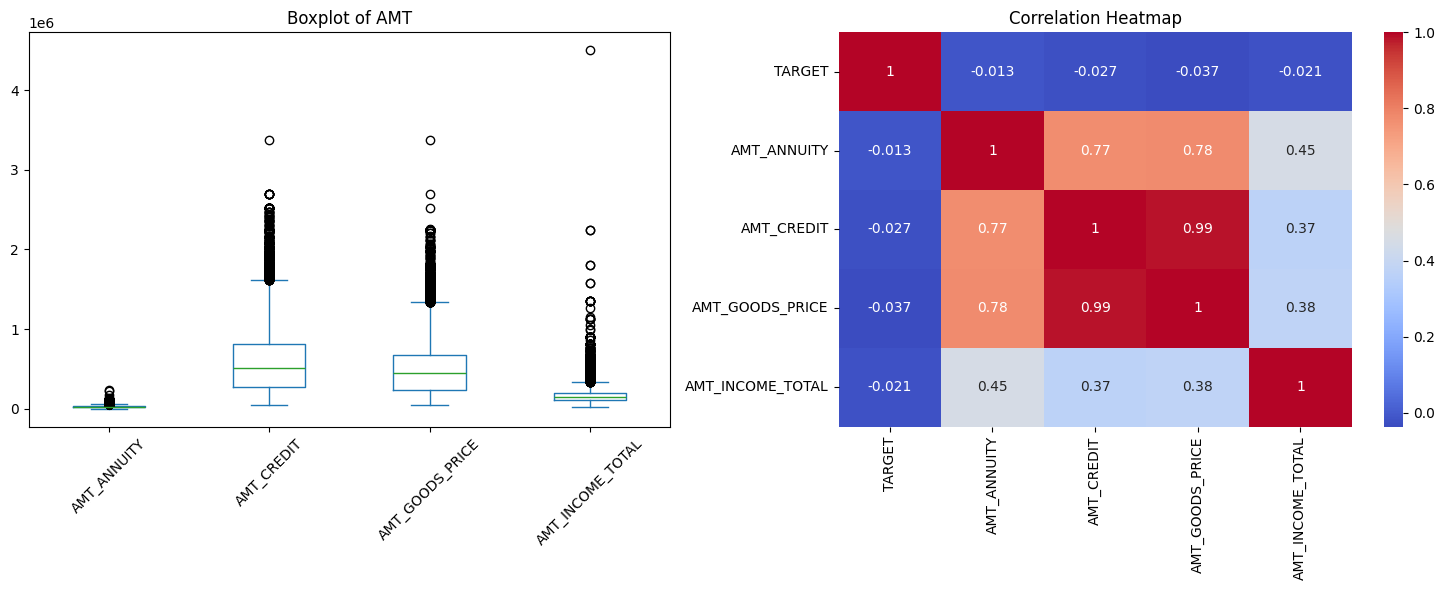

In [1694]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[amt].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + amt].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

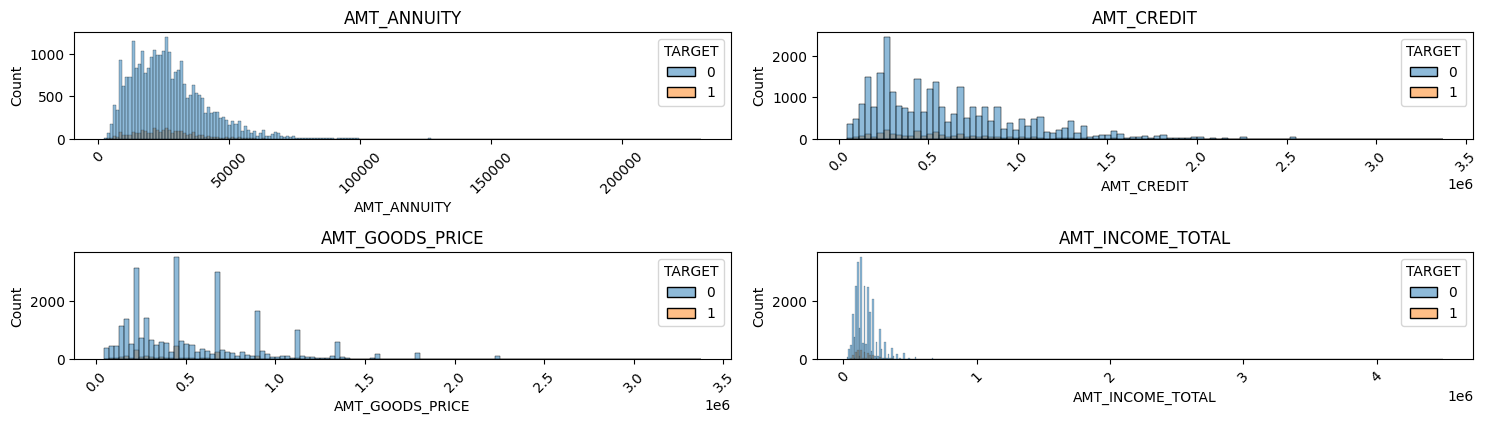

In [1695]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[amt].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Amount Required Credit Bureau

In [1696]:
amt_req_credit_bureau = [
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

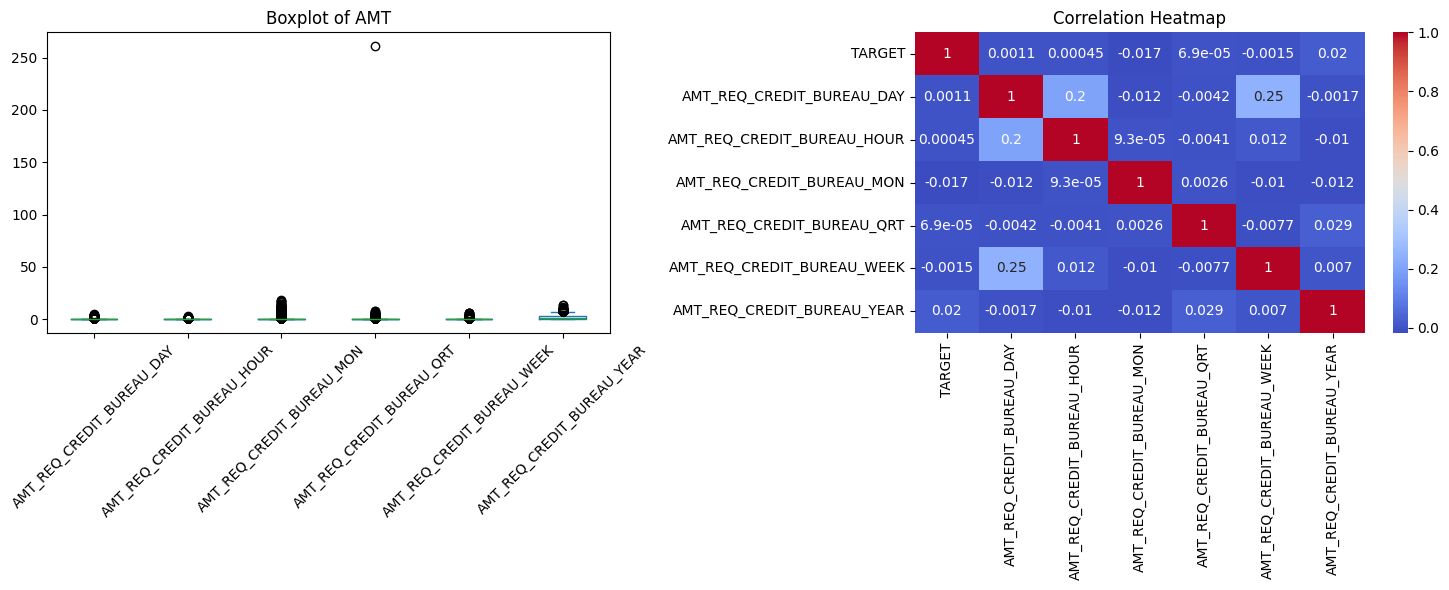

In [1697]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[amt_req_credit_bureau].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + amt_req_credit_bureau].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

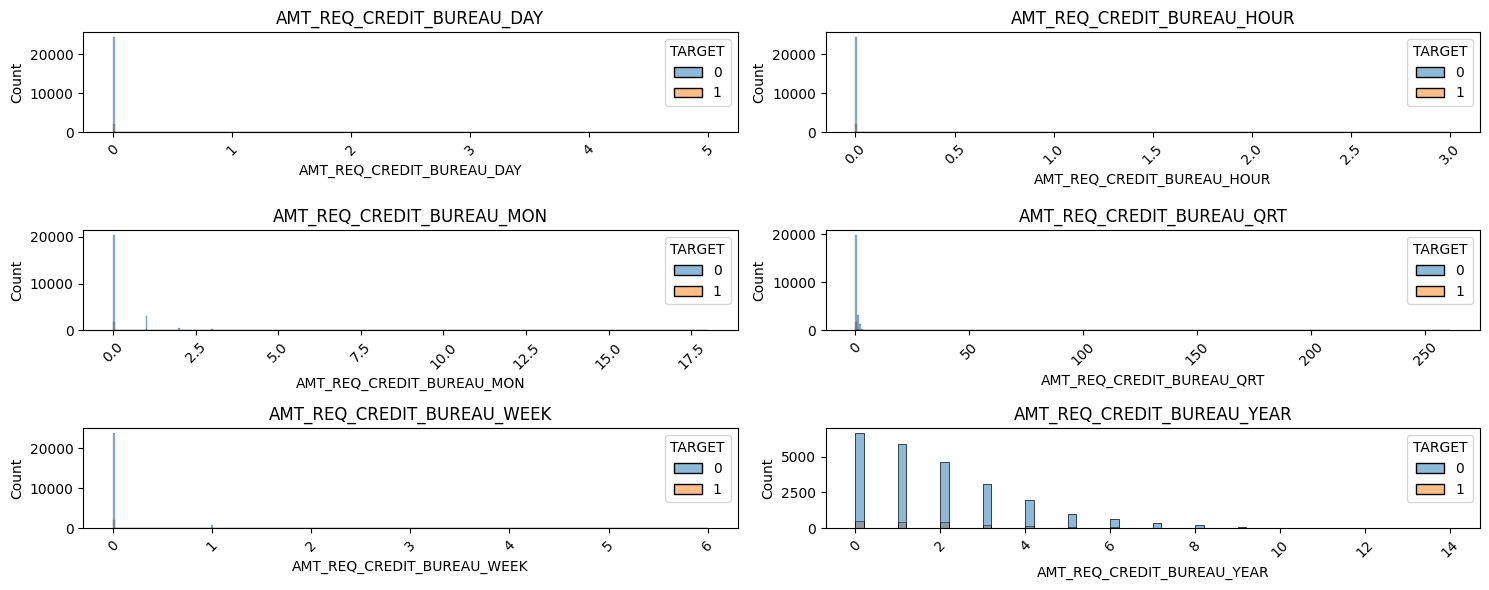

In [1698]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[amt_req_credit_bureau].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Count

In [1699]:
cnt = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]


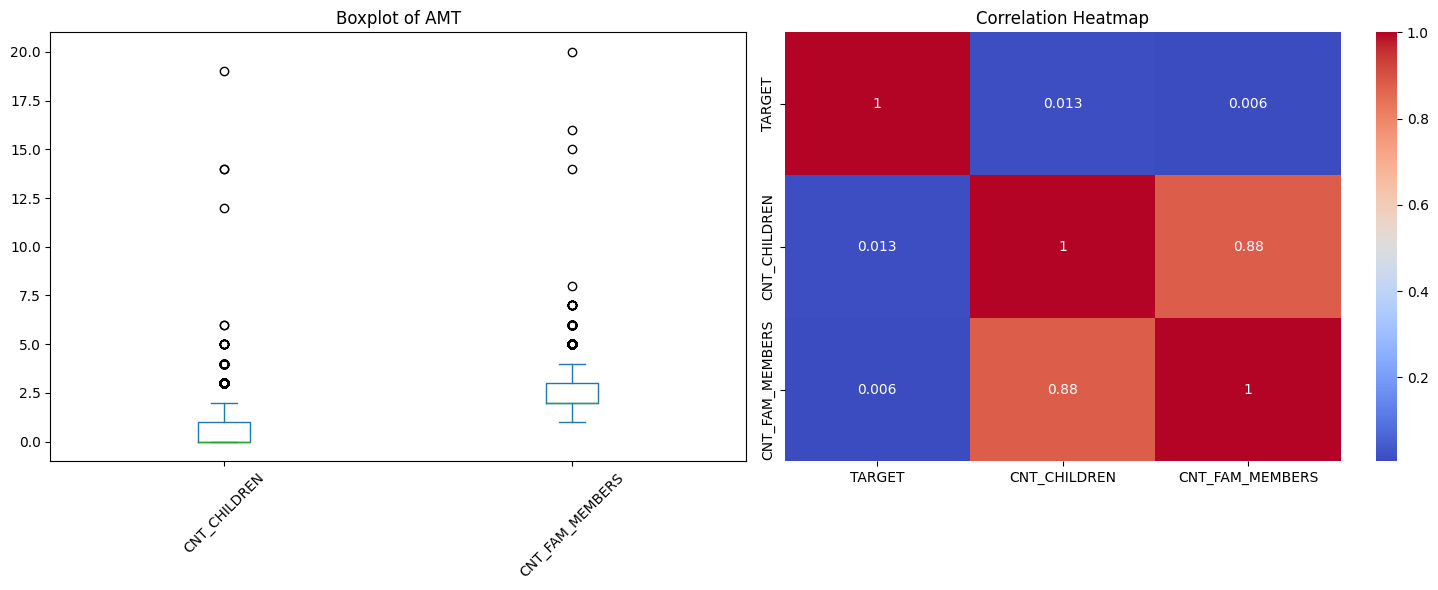

In [1700]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[cnt].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + cnt].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

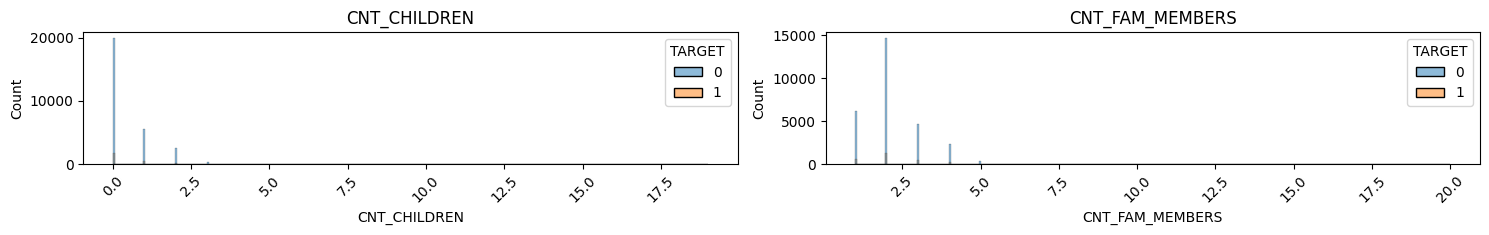

In [1701]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[cnt].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Days

In [1702]:
days = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_REGISTRATION"
]

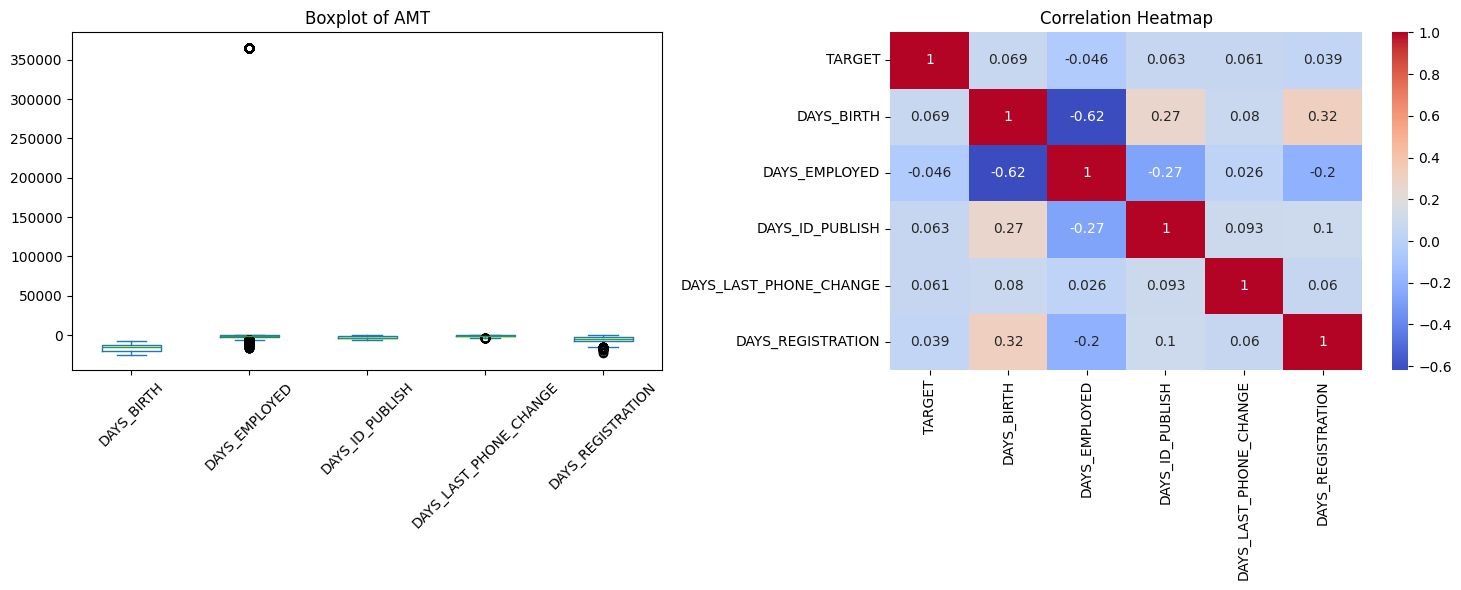

In [1703]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[days].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + days].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

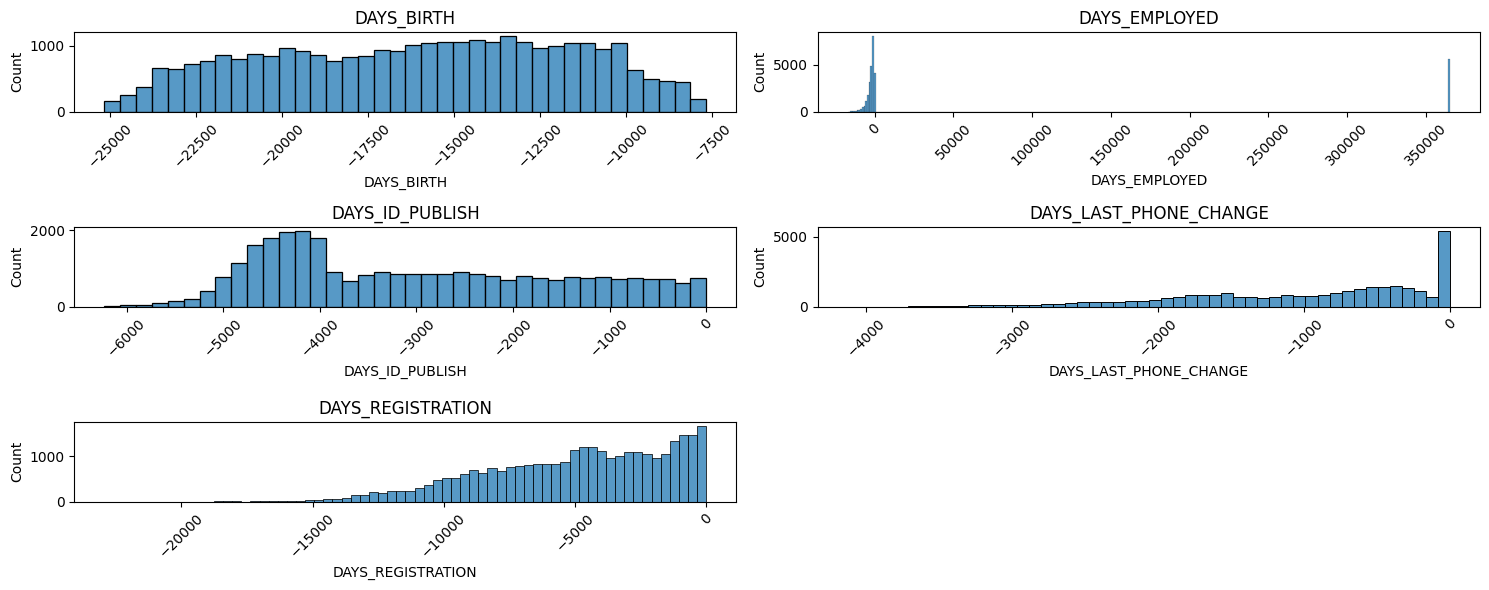

In [1704]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[days].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Social Circle

In [1705]:
social_circle = [
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE"
]

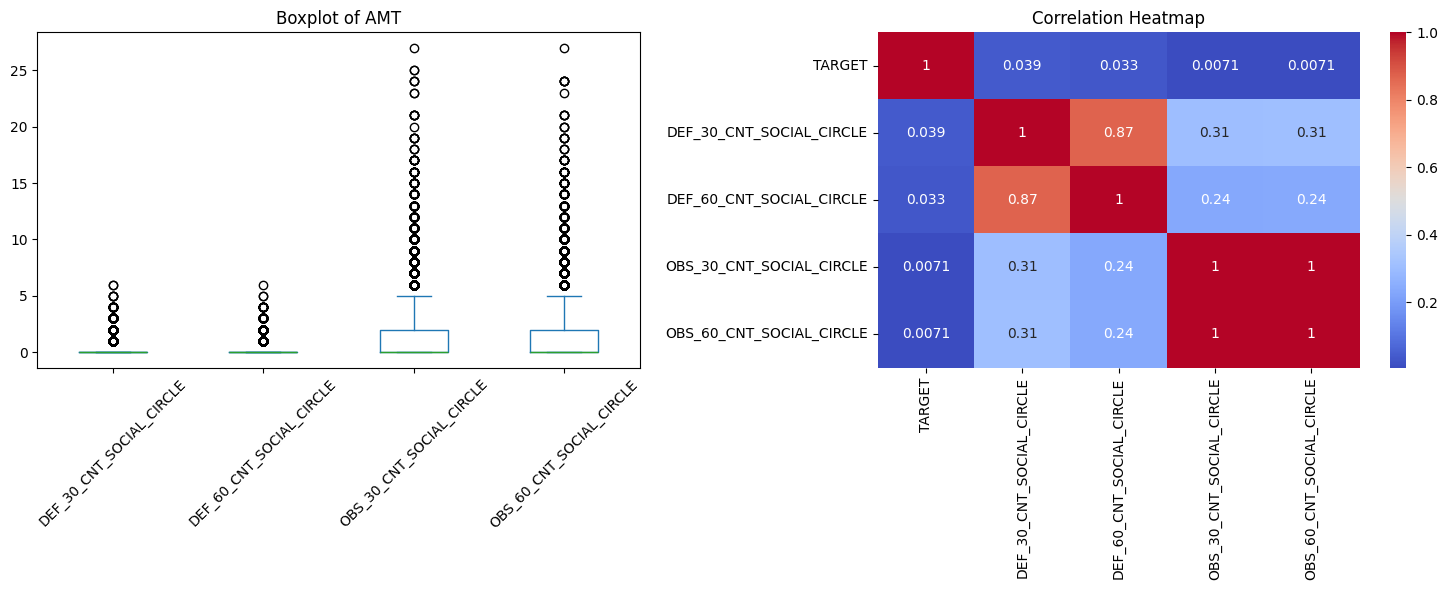

In [1706]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[social_circle].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + social_circle].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

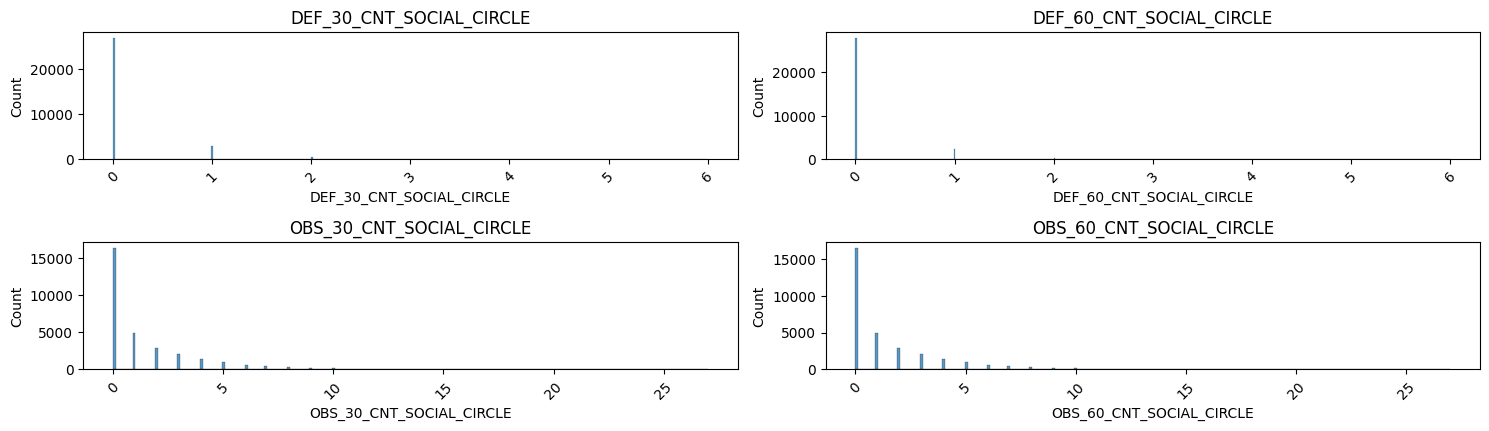

In [1707]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[social_circle].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## External Source

In [1708]:
ext_source = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

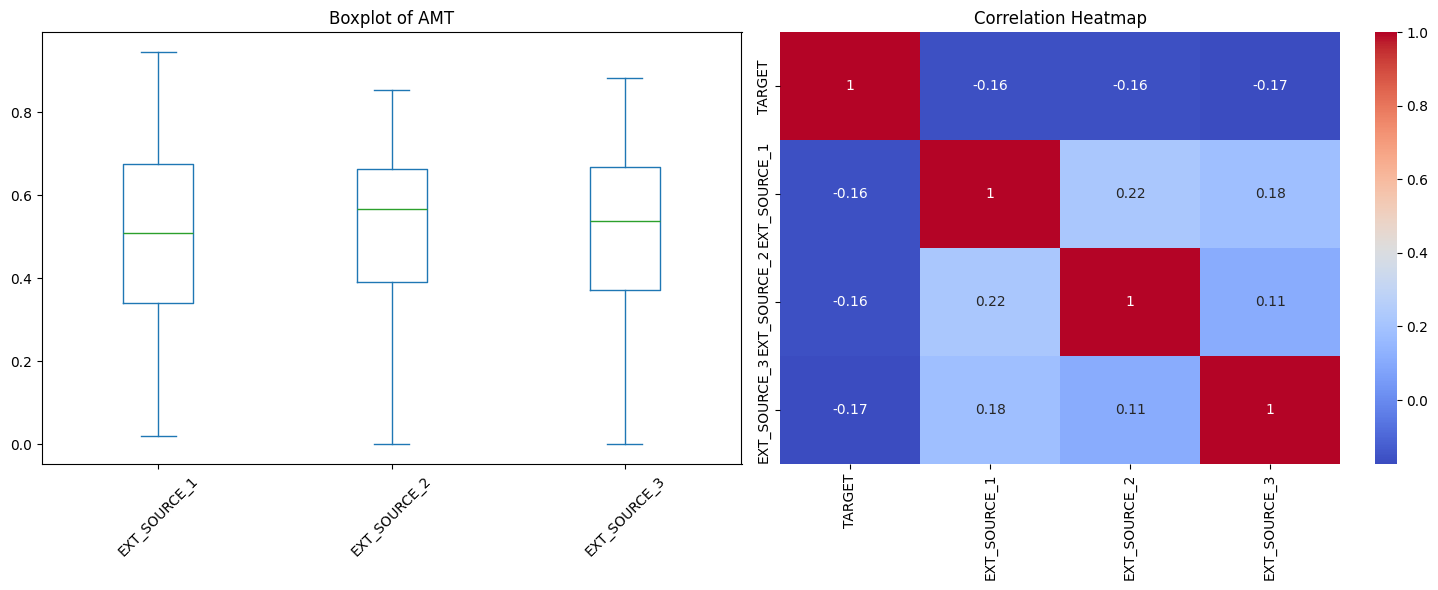

In [1709]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[ext_source].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + ext_source].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

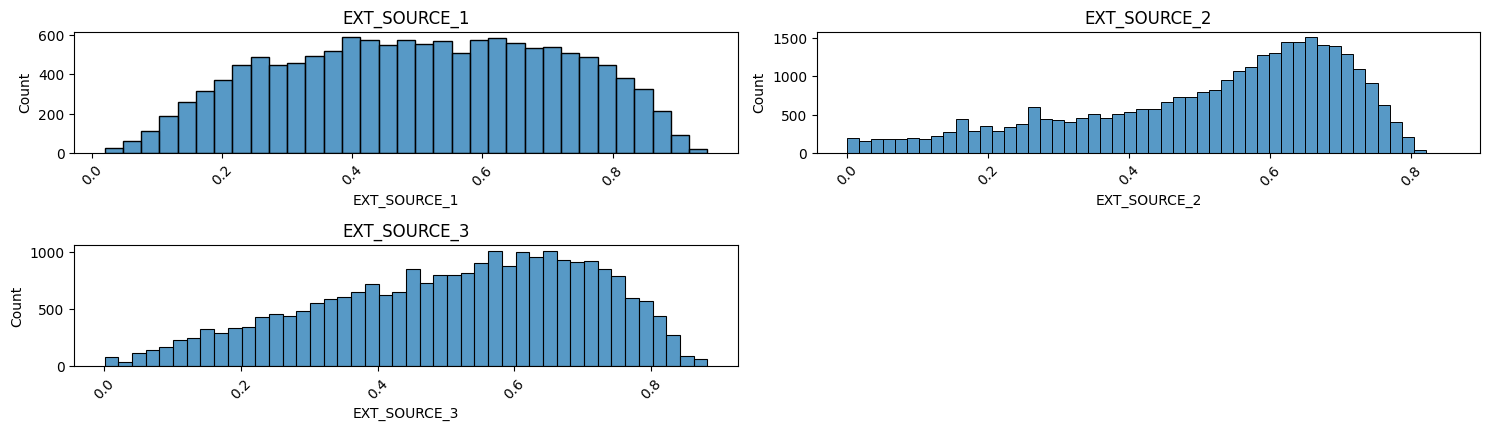

In [1710]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[ext_source].columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Flag Documents

In [1711]:
flag_documents = [
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_3",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_5",
    "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_8",
    "FLAG_DOCUMENT_9",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_20",
    "FLAG_DOCUMENT_21"
]

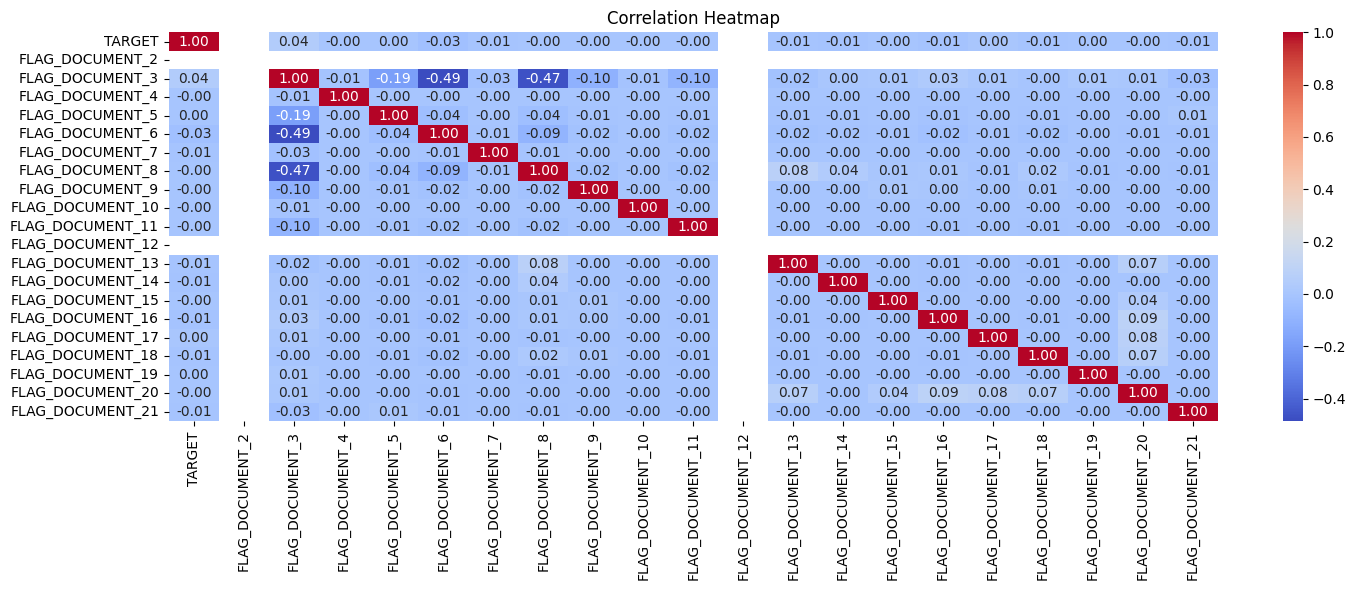

In [1712]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

sns.heatmap(df[['TARGET'] + flag_documents].corr(), annot=True, cmap='coolwarm', ax=ax, fmt = '.2f')
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Flag Contact Info Features

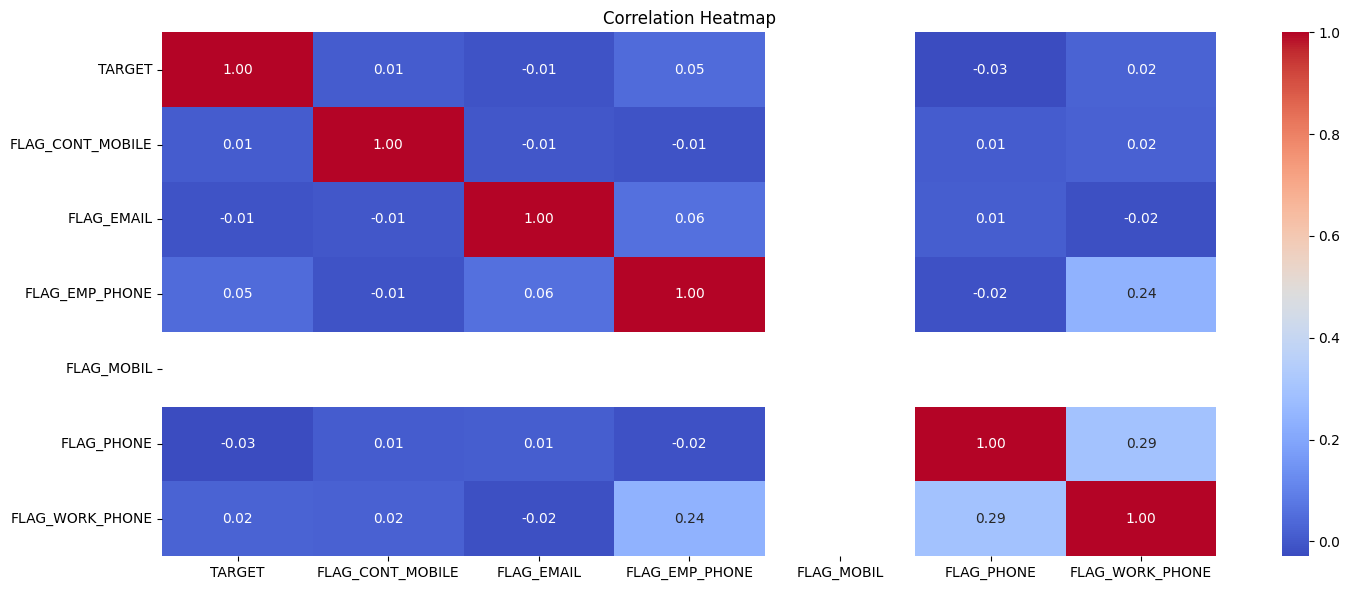

In [1713]:
flag_contact_info = [
    "FLAG_CONT_MOBILE",
    "FLAG_EMAIL",
    "FLAG_EMP_PHONE",
    "FLAG_MOBIL",
    "FLAG_PHONE",
    "FLAG_WORK_PHONE"
]

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

sns.heatmap(df[['TARGET'] + flag_contact_info].corr(), annot=True, cmap='coolwarm', ax=ax, fmt = '.2f')
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

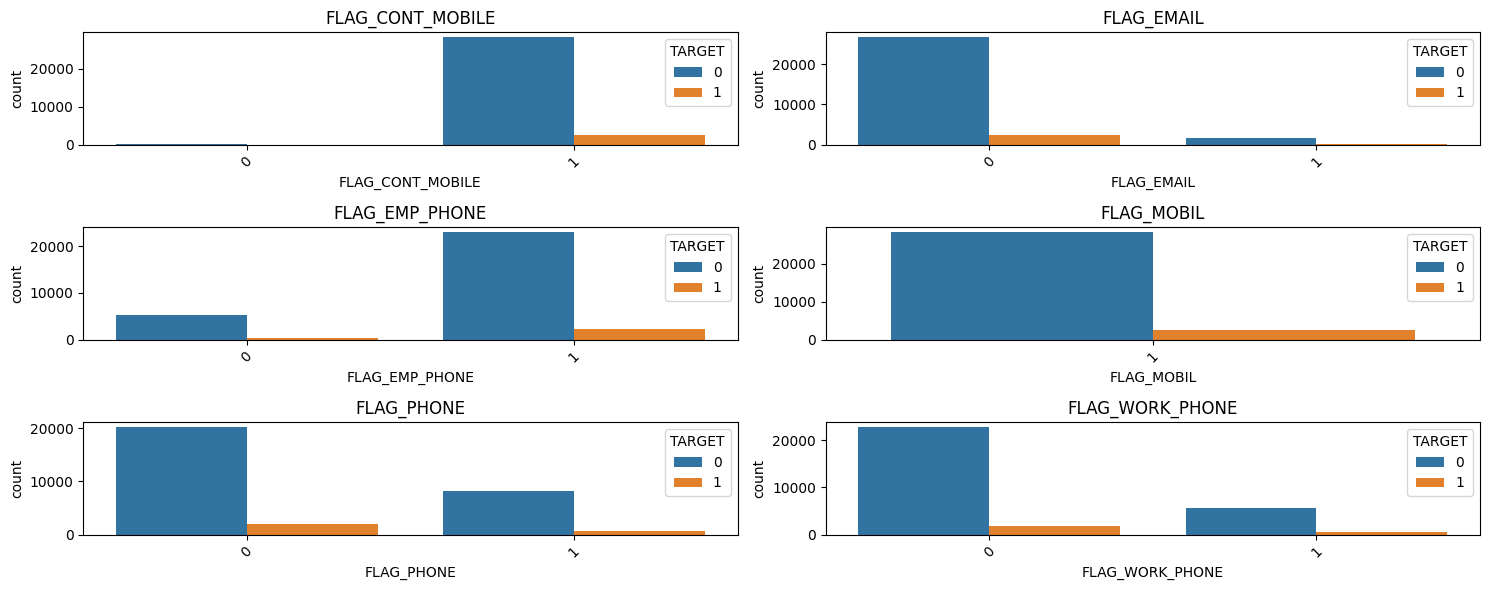

In [1714]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[flag_contact_info].columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, hue = 'TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Flag Assets

In [1715]:
flag_assets = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "OWN_CAR_AGE"
]

df[flag_assets]


,FLAG_OWN_CAR,FLAG_OWN_REALTY,OWN_CAR_AGE
255322,N,Y,NaN
296139,Y,Y,65.0
243811,N,N,NaN
151067,N,N,NaN
128786,Y,N,28.0
...,...,...,...
229360,Y,Y,18.0
44701,N,Y,NaN
255894,N,Y,NaN
140436,N,N,NaN


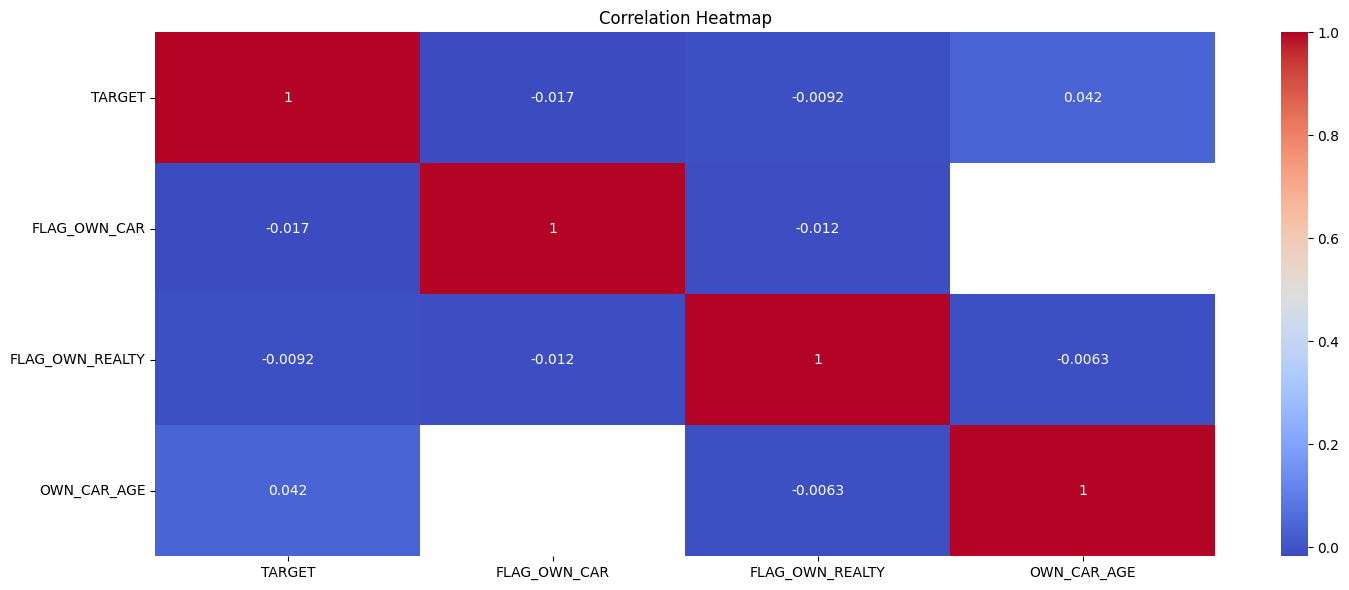

In [1716]:
flag_assets_dummies = df[flag_assets + ['TARGET']]
flag_assets_dummies['FLAG_OWN_CAR'] = flag_assets_dummies['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1})
flag_assets_dummies['FLAG_OWN_REALTY'] = flag_assets_dummies['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1})

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

sns.heatmap(flag_assets_dummies[['TARGET'] + flag_assets].corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

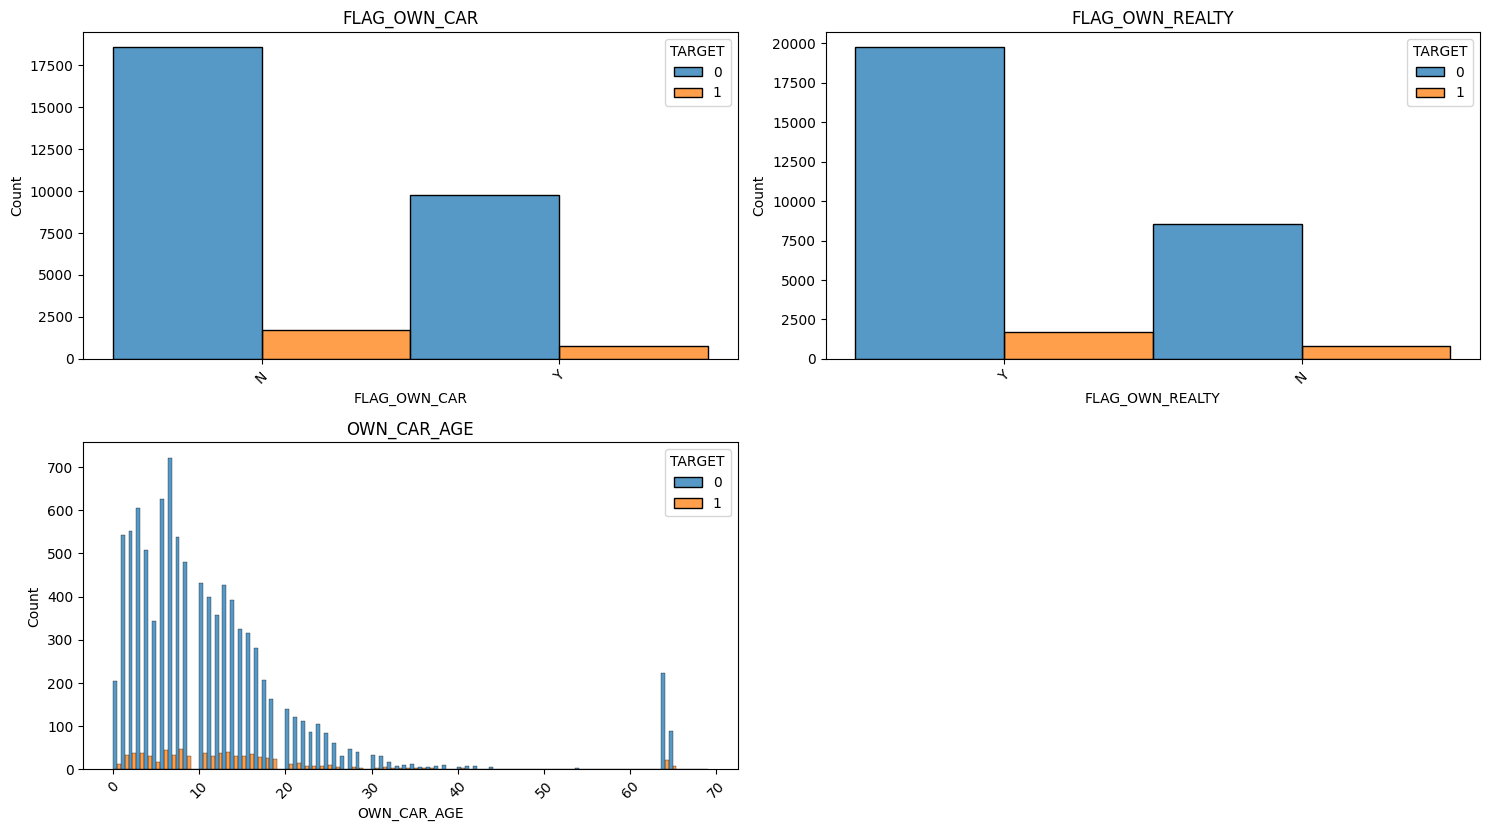

In [1717]:
import matplotlib.pyplot as plt
import seaborn as sns

# Increased the height to 12 so the 3 rows have room to breathe
plt.figure(figsize=(15, 12))

# Loop directly through the list of column names
for i, col in enumerate(flag_assets):
    
    if i >= 6:
        print(f"Note: Reached the 6-plot limit of the 3x2 grid. Skipping remaining columns.")
        break

    plt.subplot(3, 2, i+1)
    
    sns.histplot(x=col, data=df, hue='TARGET', multiple='dodge')
    
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

## Name

In [1718]:
name = [
    "NAME_CONTRACT_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_TYPE_SUITE"
]

In [1719]:
name_dummies = pd.get_dummies(df[name], columns=name).astype(int)
name_dummies['TARGET'] = df['TARGET']


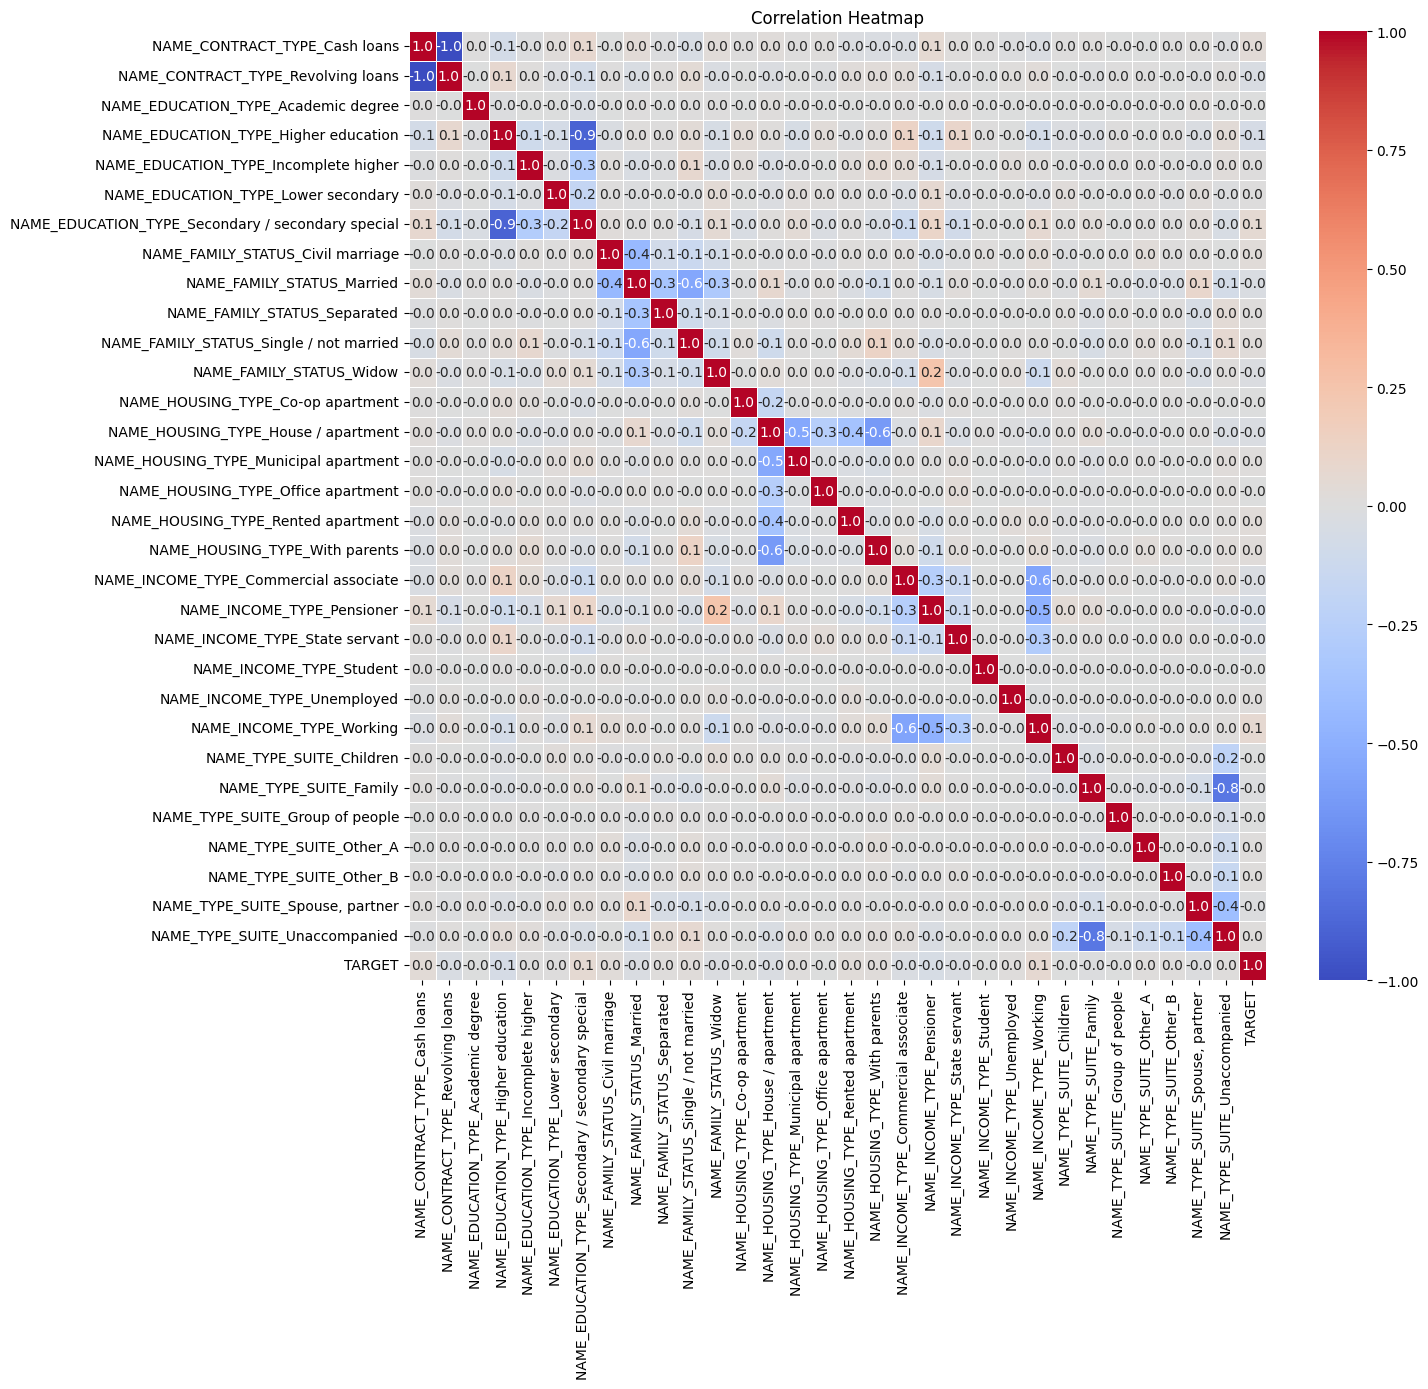

In [1720]:
fig, ax = plt.subplots(1, 1, figsize=(15, 14))

sns.heatmap(name_dummies.corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.1f', linewidths=0.5)
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

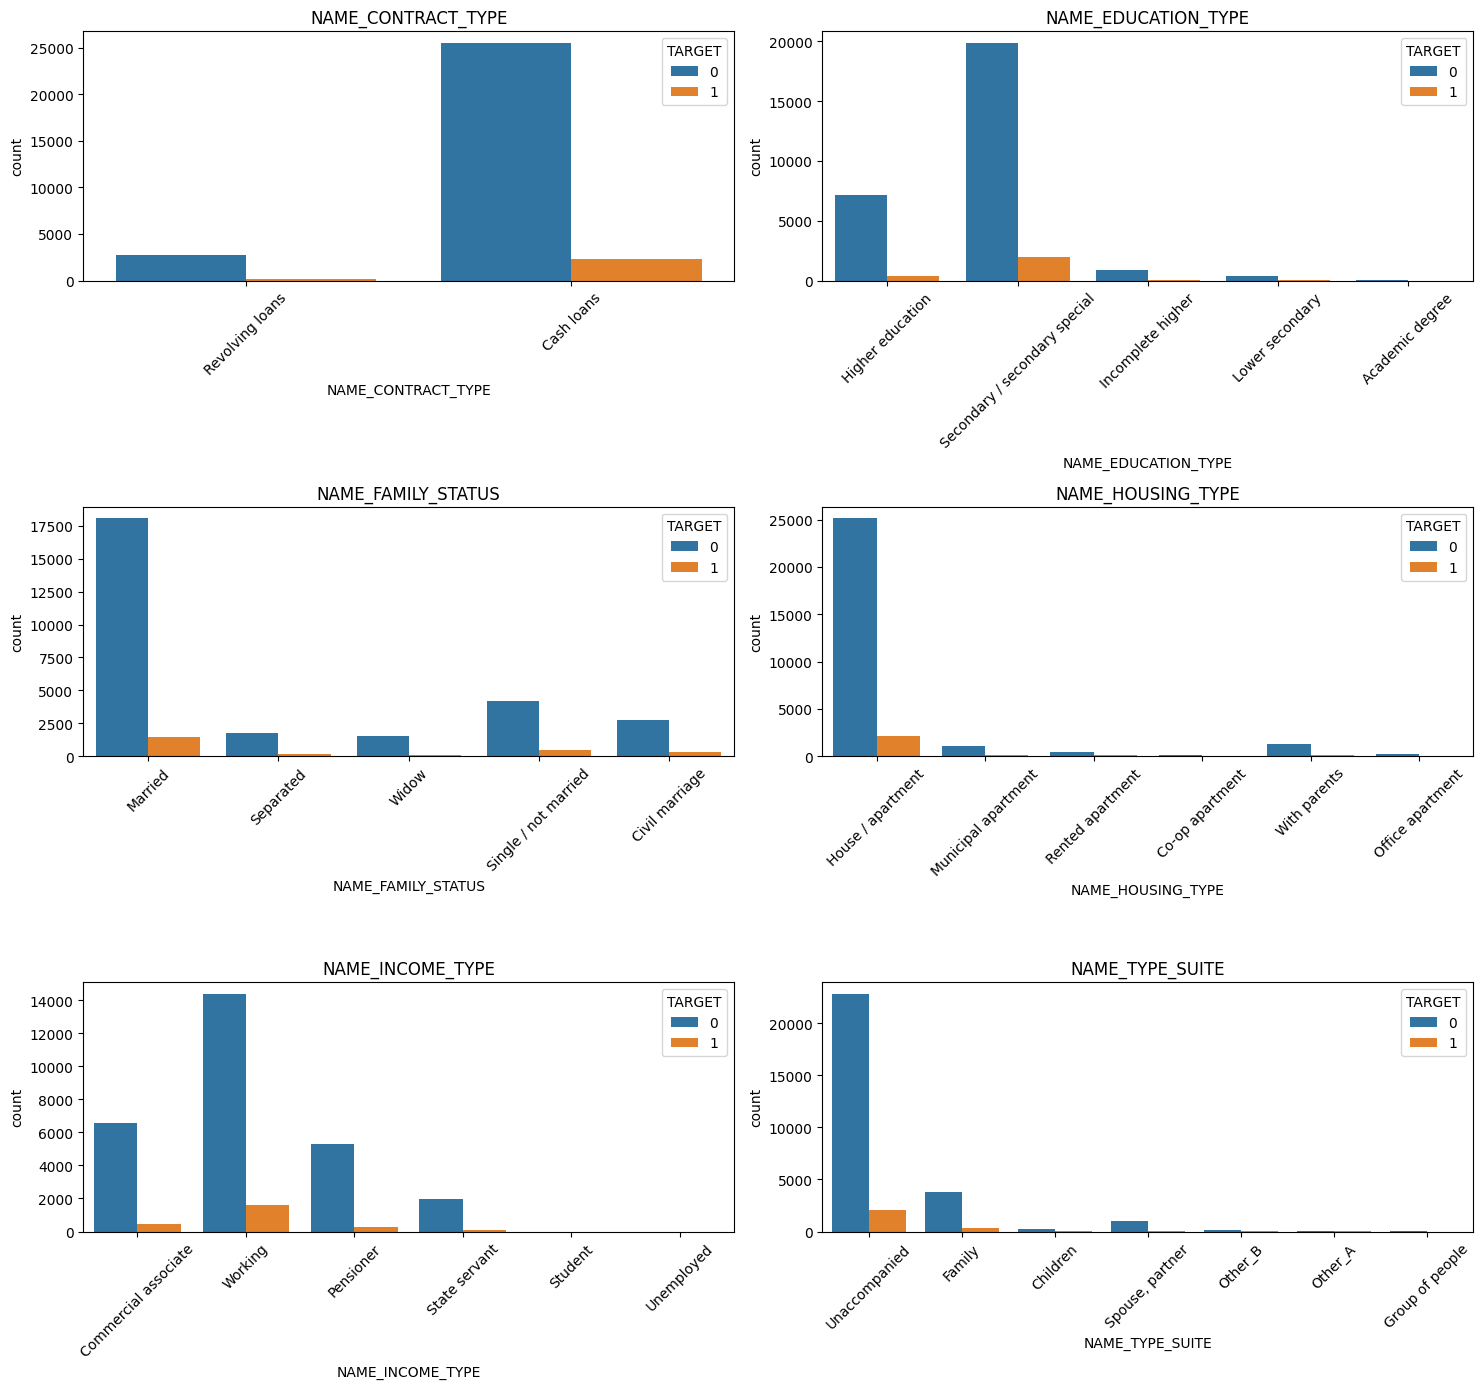

In [1721]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 14))

for i, col in enumerate(name):
    
    if i >= 6:
        print("Note: Reached the 6-plot limit. Skipping the rest.")
        break
        
    plt.subplot(3, 2, i+1)
    
    ax = sns.countplot(x=col, data=df, hue='TARGET')
    
    plt.xticks(rotation=45)
    plt.title(col)
    
    if ax.get_legend() is not None:
        ax.legend(title='TARGET', loc='upper right')

plt.tight_layout()
plt.show()

## Region & City Match

In [1722]:
region_city_match = [
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION"
]

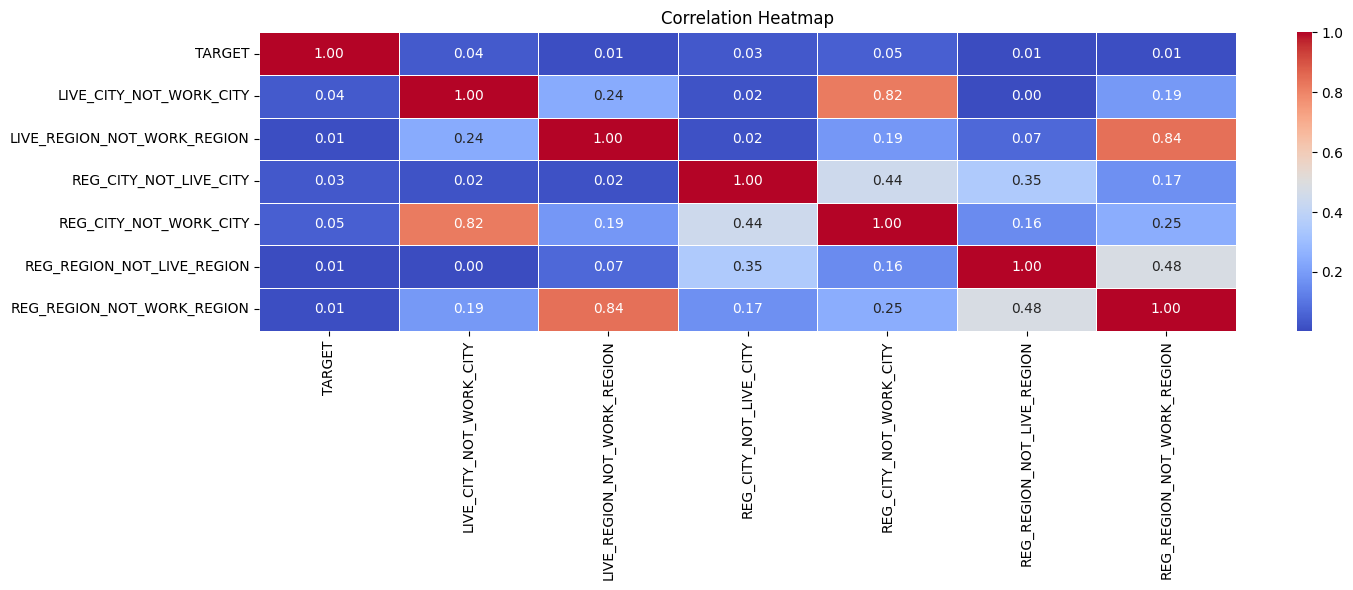

In [1723]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

sns.heatmap(df[['TARGET'] + region_city_match].corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.2f', linewidths=0.5)
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

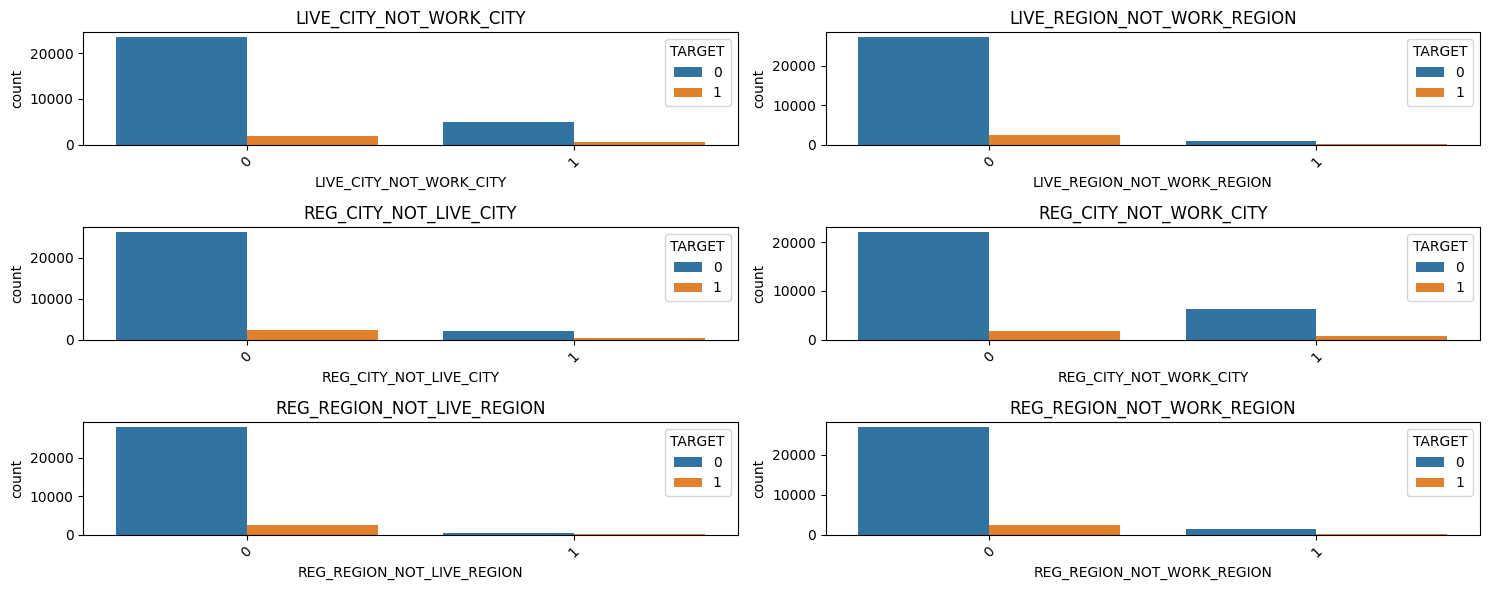

In [1724]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(df[region_city_match].columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, hue = 'TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Region Rating

In [1725]:
region_rating = [
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY"
]

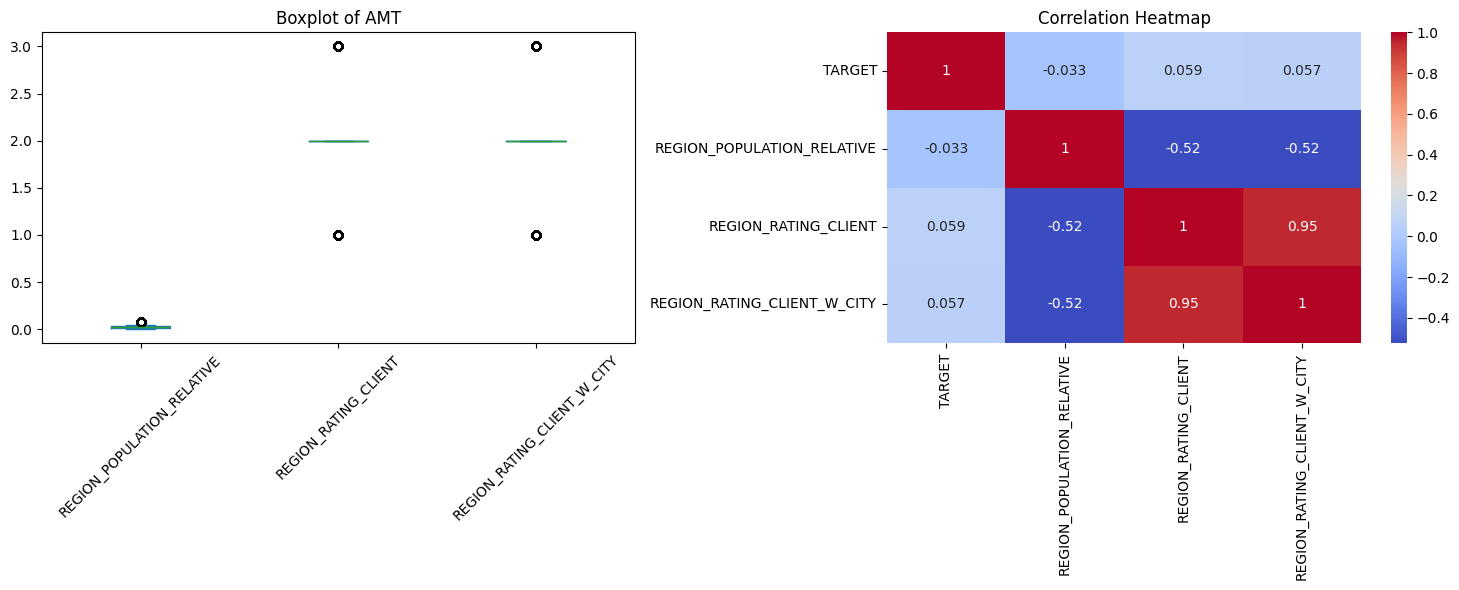

In [1726]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[region_rating].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + region_rating].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

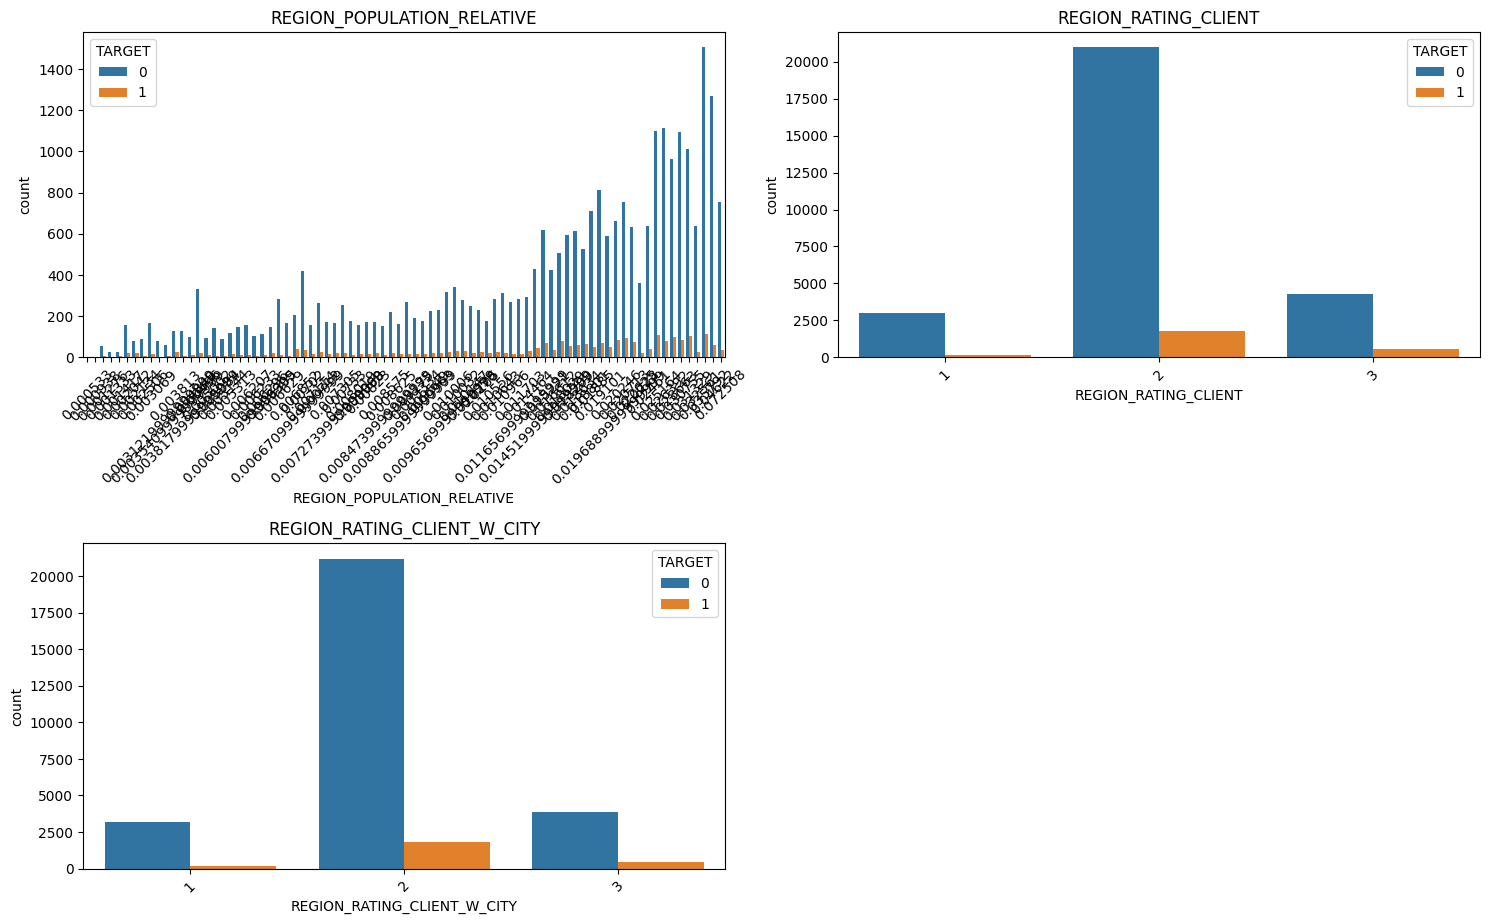

In [1727]:
plt.figure(figsize=(15, 14))
for i, col in enumerate(df[region_rating].columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Housing Features

In [1728]:
housing_features = [
    "APARTMENTS_AVG", "APARTMENTS_MEDI", "APARTMENTS_MODE",
    "BASEMENTAREA_AVG", "BASEMENTAREA_MEDI", "BASEMENTAREA_MODE",
    "COMMONAREA_AVG", "COMMONAREA_MEDI", "COMMONAREA_MODE",
    "ELEVATORS_AVG", "ELEVATORS_MEDI", "ELEVATORS_MODE",
    "ENTRANCES_AVG", "ENTRANCES_MEDI", "ENTRANCES_MODE",
    "FLOORSMAX_AVG", "FLOORSMAX_MEDI", "FLOORSMAX_MODE",
    "FLOORSMIN_AVG", "FLOORSMIN_MEDI", "FLOORSMIN_MODE",
    "LANDAREA_AVG", "LANDAREA_MEDI", "LANDAREA_MODE",
    "LIVINGAPARTMENTS_AVG", "LIVINGAPARTMENTS_MEDI", "LIVINGAPARTMENTS_MODE",
    "LIVINGAREA_AVG", "LIVINGAREA_MEDI", "LIVINGAREA_MODE",
    "NONLIVINGAPARTMENTS_AVG", "NONLIVINGAPARTMENTS_MEDI", "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAREA_AVG", "NONLIVINGAREA_MEDI", "NONLIVINGAREA_MODE",
    "FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "TOTALAREA_MODE",
    "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"
]

In [1729]:
df[['FLAG_OWN_REALTY'] + housing_features].sample()


,FLAG_OWN_REALTY,APARTMENTS_AVG,APARTMENTS_MEDI,APARTMENTS_MODE,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,BASEMENTAREA_MODE,COMMONAREA_AVG,COMMONAREA_MEDI,COMMONAREA_MODE,...,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
187016,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


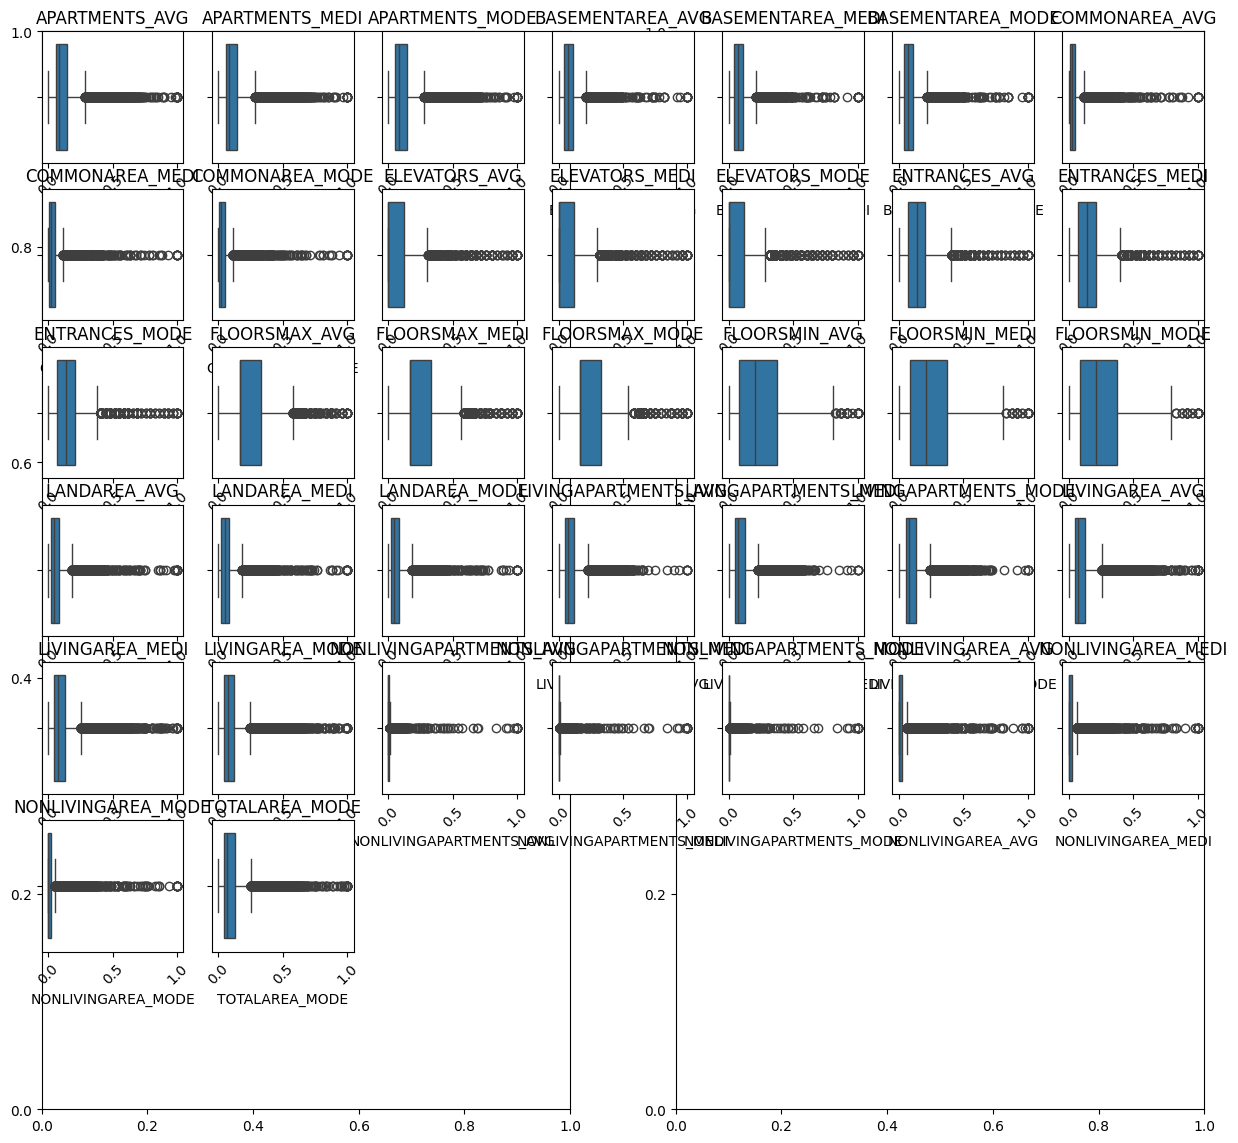

In [1730]:
fig, ax = plt.subplots(1, 2, figsize=(15, 14))

for i, col in enumerate(df[housing_features].select_dtypes(include=['number']).columns):
    plt.subplot(7, 7, i+1)
    sns.boxplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)

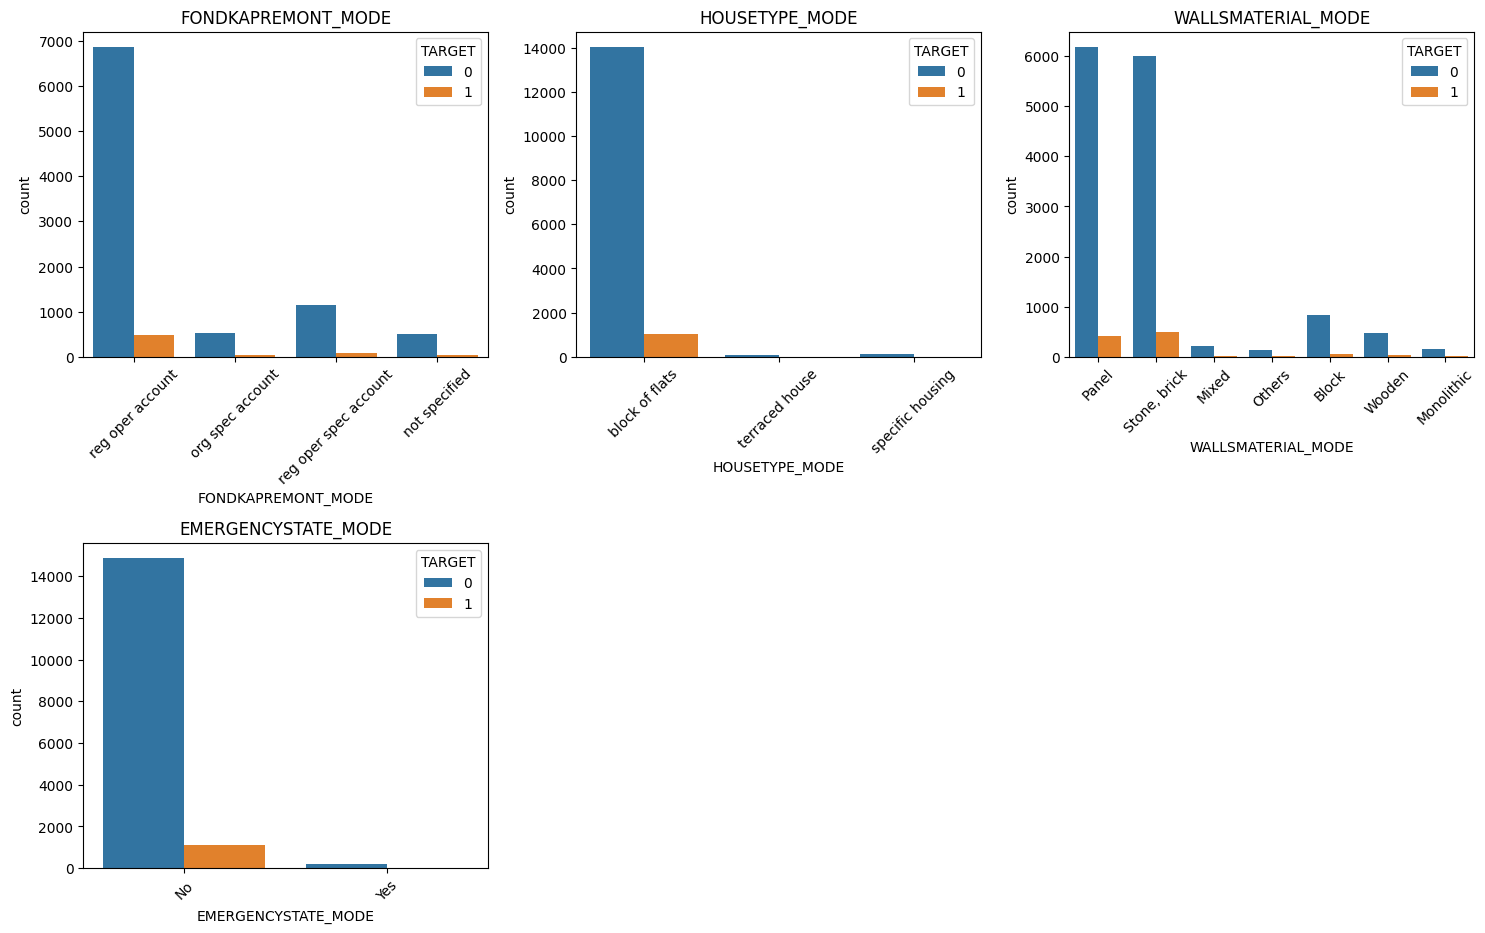

In [1731]:
plt.figure(figsize=(15, 14))
for i, col in enumerate(df[housing_features].select_dtypes(include=['string']).columns):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Years

In [1732]:
years = [
    "YEARS_BEGINEXPLUATATION_AVG",
    "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BEGINEXPLUATATION_MODE",
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MEDI",
    "YEARS_BUILD_MODE"
]

In [1733]:
df[['FLAG_OWN_REALTY'] + years].sample(5)

,FLAG_OWN_REALTY,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,YEARS_BUILD_MODE
49169,Y,NaN,NaN,NaN,NaN,NaN,NaN
129799,Y,0.9697,0.9697,0.9697,NaN,NaN,NaN
258693,Y,0.9911,0.9911,0.9911,0.8776,0.8792,0.8824
301124,Y,0.9811,0.9811,0.9811,NaN,NaN,NaN
37053,Y,NaN,NaN,NaN,NaN,NaN,NaN


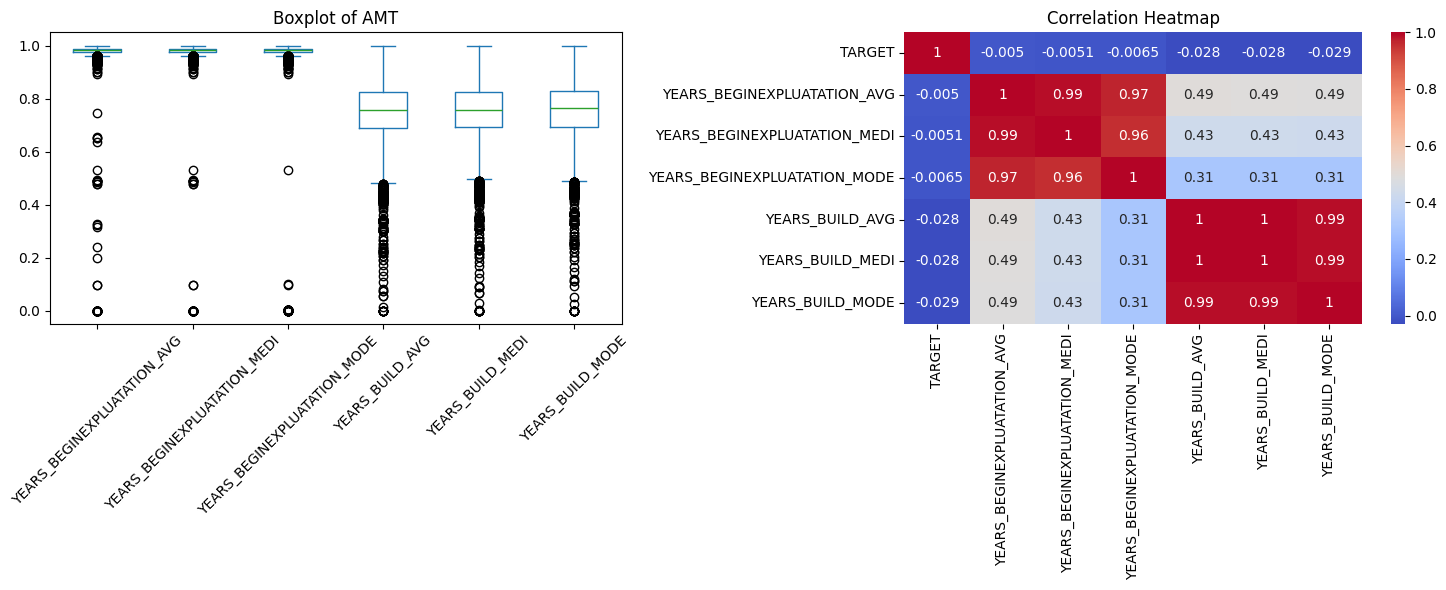

In [1734]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df[years].plot(kind='box', ax=ax[0], rot=45)
ax[0].set_title('Boxplot of AMT')

sns.heatmap(df[['TARGET'] + years].corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

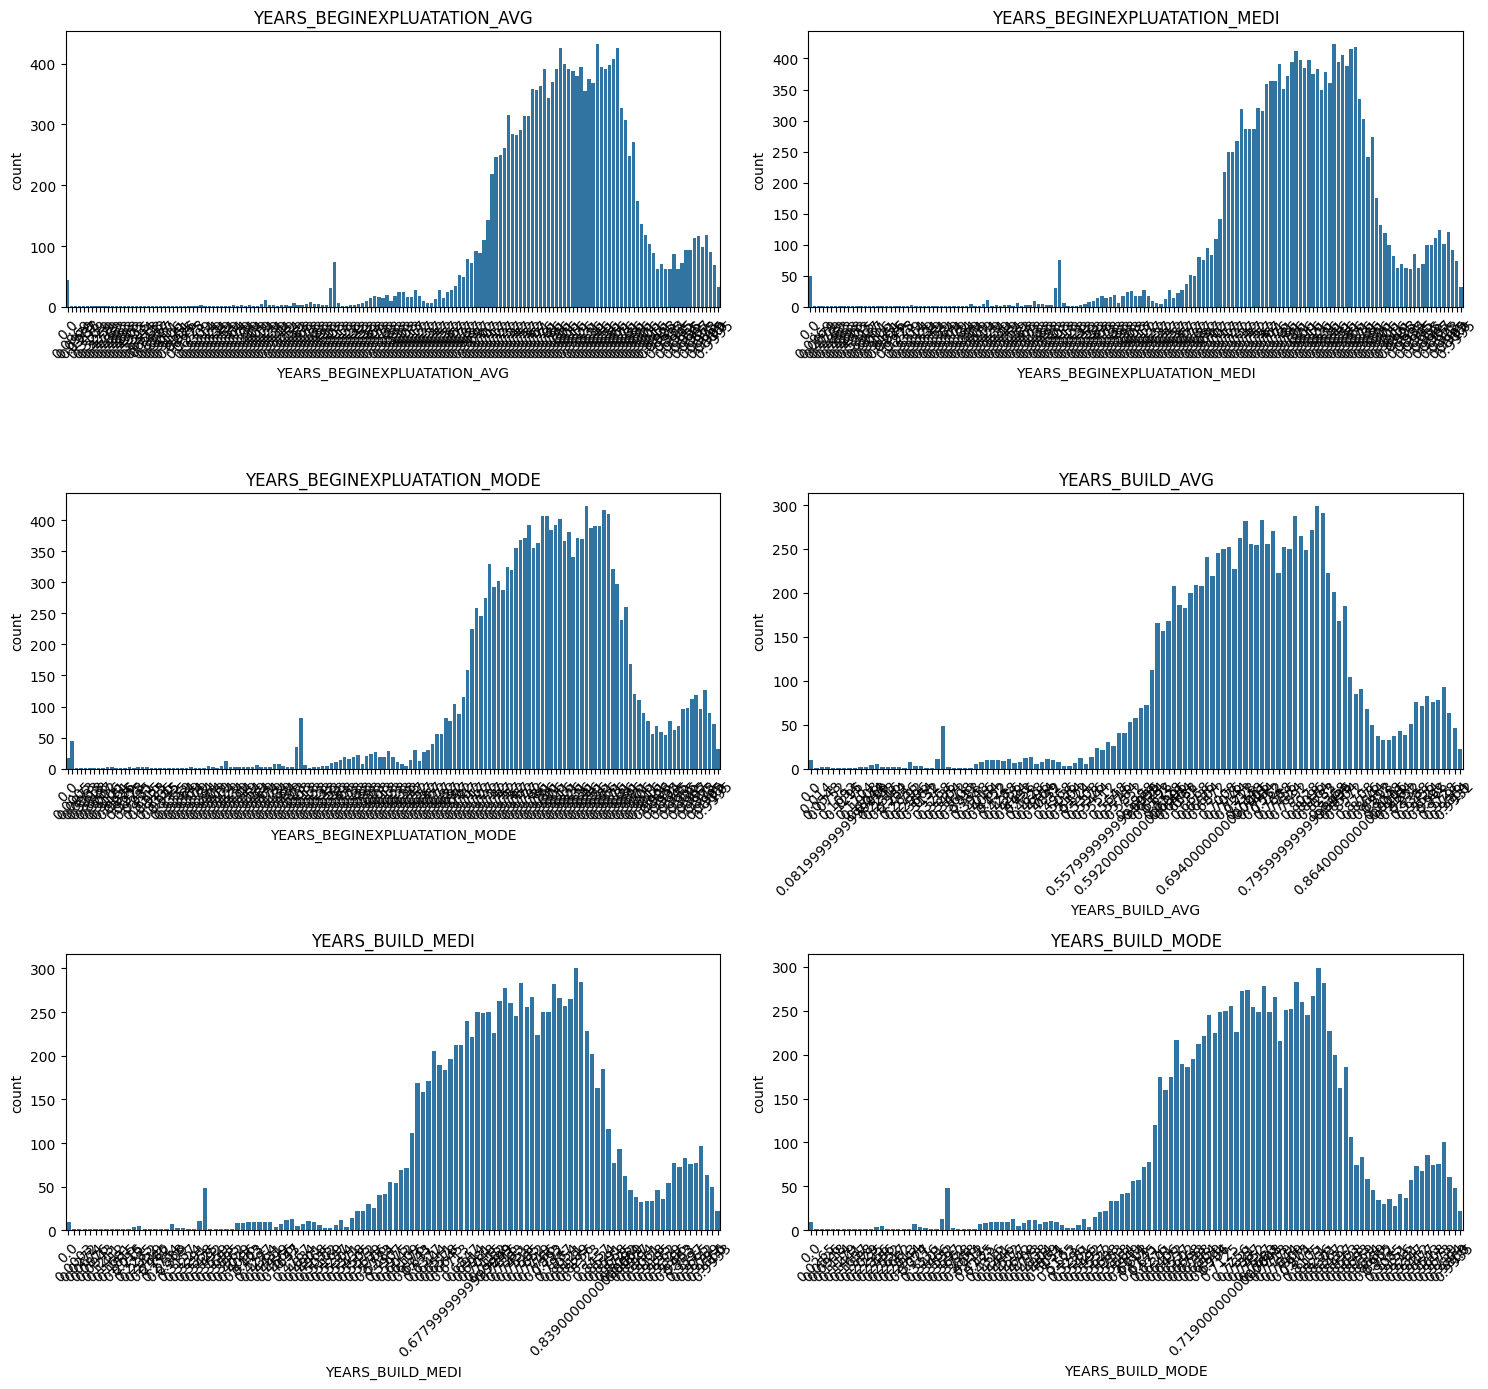

In [1735]:
plt.figure(figsize=(15, 14))
for i, col in enumerate(df[years].columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

## Misc

In [1736]:
misc = [
    "CODE_GENDER",
    "HOUR_APPR_PROCESS_START",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "WEEKDAY_APPR_PROCESS_START"
]

<Axes: >

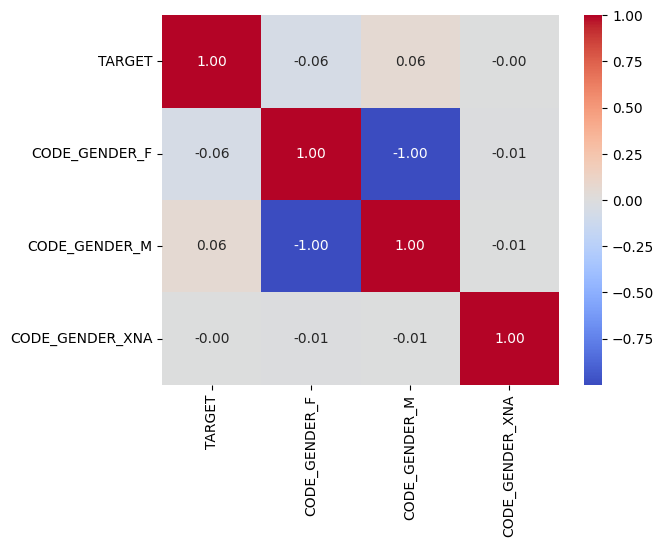

In [1737]:
gender_encoded = df[['CODE_GENDER', 'TARGET']]
gender_encoded = pd.get_dummies(gender_encoded, columns=['CODE_GENDER'])
sns.heatmap(gender_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')

In [1738]:
occupation_dummies = df[['TARGET', 'OCCUPATION_TYPE']]
occupation_dummies = pd.get_dummies(occupation_dummies, columns=['OCCUPATION_TYPE'])
occupation_dummies.corr()['TARGET']

TARGET                                   1.000000
OCCUPATION_TYPE_Accountants             -0.018886
OCCUPATION_TYPE_Cleaning staff           0.005678
OCCUPATION_TYPE_Cooking staff            0.011321
OCCUPATION_TYPE_Core staff              -0.031885
OCCUPATION_TYPE_Drivers                  0.036189
OCCUPATION_TYPE_HR staff                -0.010132
OCCUPATION_TYPE_High skill tech staff   -0.019605
OCCUPATION_TYPE_IT staff                -0.000577
OCCUPATION_TYPE_Laborers                 0.052645
OCCUPATION_TYPE_Low-skill Laborers       0.021192
OCCUPATION_TYPE_Managers                -0.015837
OCCUPATION_TYPE_Medicine staff          -0.017143
OCCUPATION_TYPE_Private service staff   -0.003776
OCCUPATION_TYPE_Realty agents           -0.002303
OCCUPATION_TYPE_Sales staff              0.014784
OCCUPATION_TYPE_Secretaries             -0.001058
OCCUPATION_TYPE_Security staff           0.024761
OCCUPATION_TYPE_Waiters/barmen staff     0.003236
Name: TARGET, dtype: float64

In [1739]:
organization_dummies = df[['TARGET', 'ORGANIZATION_TYPE']]
organization_dummies = pd.get_dummies(organization_dummies, columns=['ORGANIZATION_TYPE'])
# Show only 'TARGET' corr
organization_dummies.corr()['TARGET']


TARGET                                      1.000000
ORGANIZATION_TYPE_Advertising              -0.001027
ORGANIZATION_TYPE_Agriculture              -0.001081
ORGANIZATION_TYPE_Bank                     -0.016496
ORGANIZATION_TYPE_Business Entity Type 1    0.008022
ORGANIZATION_TYPE_Business Entity Type 2    0.004696
ORGANIZATION_TYPE_Business Entity Type 3    0.024034
ORGANIZATION_TYPE_Cleaning                 -0.004266
ORGANIZATION_TYPE_Construction              0.015223
ORGANIZATION_TYPE_Culture                  -0.007207
ORGANIZATION_TYPE_Electricity              -0.006654
ORGANIZATION_TYPE_Emergency                -0.006559
ORGANIZATION_TYPE_Government                0.000662
ORGANIZATION_TYPE_Hotel                    -0.010404
ORGANIZATION_TYPE_Housing                  -0.004368
ORGANIZATION_TYPE_Industry: type 1         -0.002720
ORGANIZATION_TYPE_Industry: type 10        -0.000730
ORGANIZATION_TYPE_Industry: type 11         0.013179
ORGANIZATION_TYPE_Industry: type 12        -0.

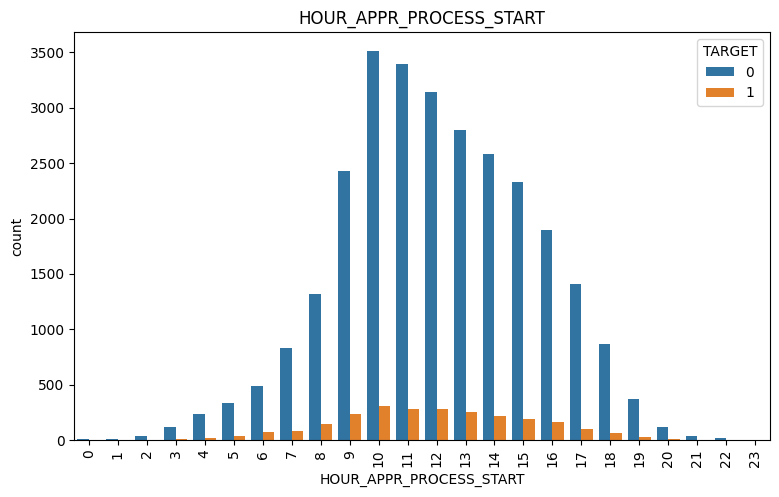

In [1740]:
plt.figure(figsize=(15, 14))
for i, col in enumerate(df[misc].select_dtypes(include=['number']).columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=90)
    plt.title(col)
plt.tight_layout()
plt.show()

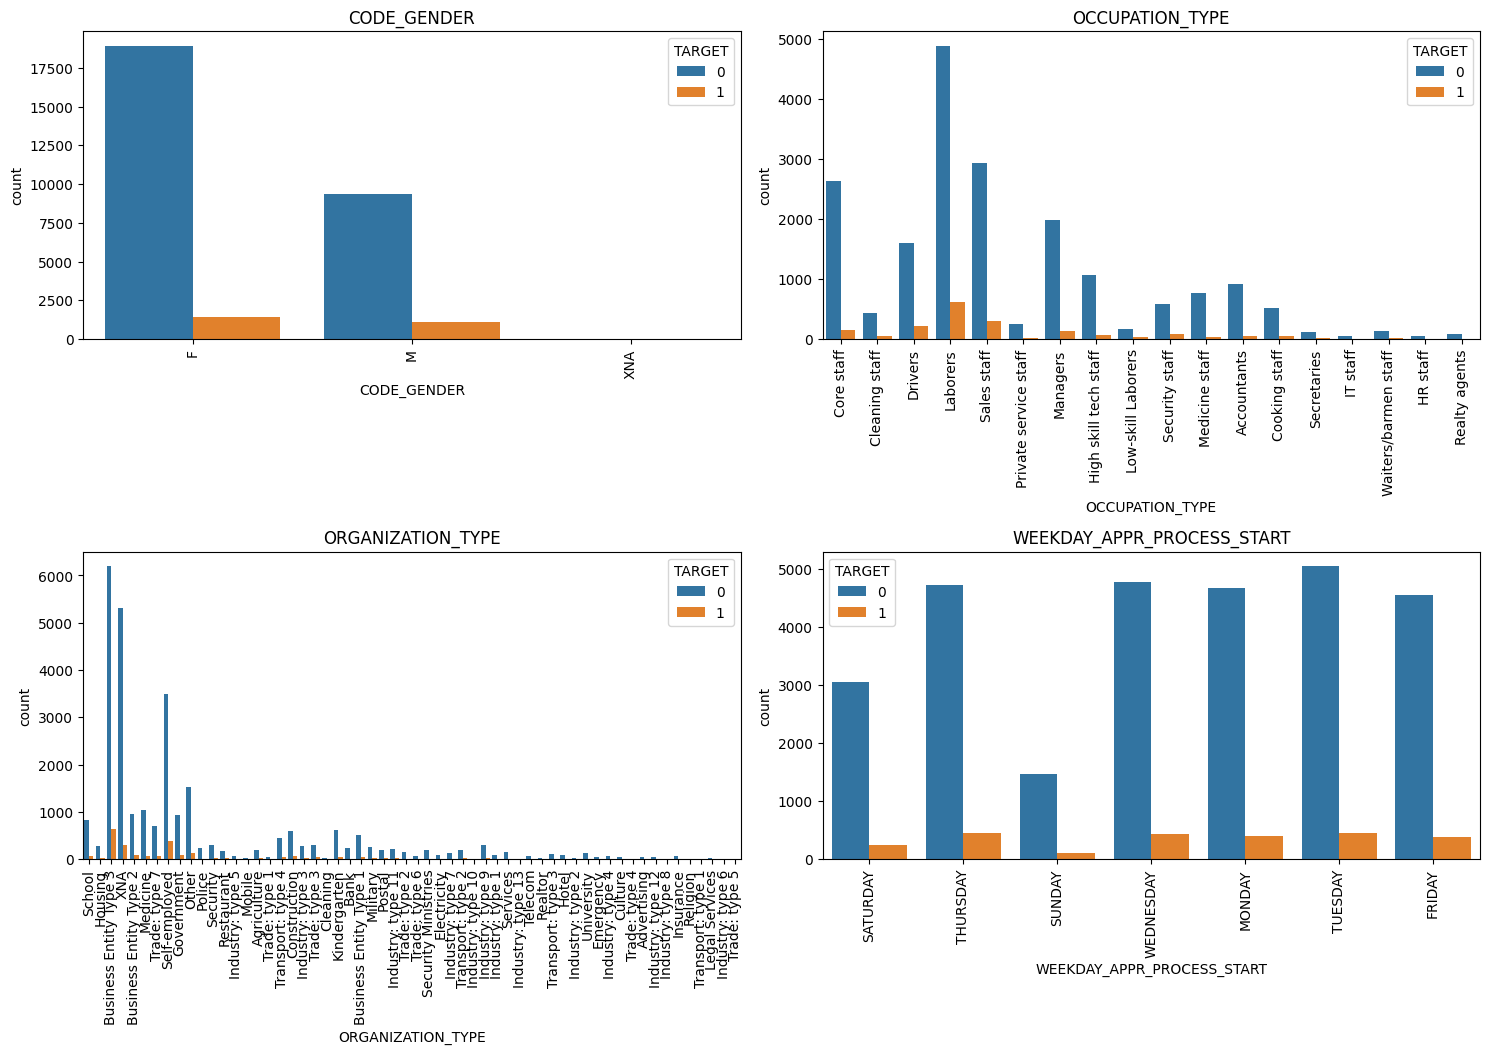

In [1741]:
plt.figure(figsize=(15, 14))
for i, col in enumerate(df[misc].select_dtypes(include=['str']).columns):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, hue='TARGET')
    plt.xticks(rotation=90)
    plt.title(col)
plt.tight_layout()
plt.show()

# Preprocessing

In [1742]:
summed_not_usable = housing_features + years

df_cleaned = loaded.copy()

df_cleaned = df_cleaned.drop(columns=summed_not_usable)
df_cleaned = df_cleaned.drop(columns=['EXT_SOURCE_1'])
df_cleaned['YEAR_EMPLOYED'] = df_cleaned['DAYS_EMPLOYED'] / 365
df_cleaned['YEAR_BIRTH'] = df_cleaned['DAYS_BIRTH'] / 365
df_cleaned = df_cleaned.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

df_cleaned.OWN_CAR_AGE = df_cleaned.OWN_CAR_AGE.where(df_cleaned.FLAG_OWN_CAR == 'Y', 0)

df_cleaned.isna().sum().sort_values(ascending=False).head(30)

OCCUPATION_TYPE               96391
EXT_SOURCE_3                  60965
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
AMT_REQ_CREDIT_BUREAU_HOUR    41519
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
NAME_TYPE_SUITE                1292
DEF_30_CNT_SOCIAL_CIRCLE       1021
DEF_60_CNT_SOCIAL_CIRCLE       1021
OBS_30_CNT_SOCIAL_CIRCLE       1021
OBS_60_CNT_SOCIAL_CIRCLE       1021
EXT_SOURCE_2                    660
AMT_GOODS_PRICE                 278
AMT_ANNUITY                      12
OWN_CAR_AGE                       5
CNT_FAM_MEMBERS                   2
DAYS_LAST_PHONE_CHANGE            1
SK_ID_CURR                        0
CNT_CHILDREN                      0
FLAG_OWN_REALTY                   0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
NAME_CONTRACT_TYPE                0
TARGET                            0
AMT_CREDIT                        0
AMT_INCOME_TOTAL            

In [1743]:
df_cleaned.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEAR_EMPLOYED,YEAR_BIRTH
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,-1.745205,-25.920548
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,-3.254795,-45.931507
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,-0.616438,-52.180822
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,-8.326027,-52.068493
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,-8.323288,-54.608219


# Pipeline

In [1744]:
X = df_cleaned.drop(columns=['TARGET'])
y = df_cleaned['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [1745]:
categorical_features = X.select_dtypes(include=['str']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['str']).columns.tolist()

In [1746]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [1747]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [1748]:
preprocessor = ColumnTransformer([
    ('categorical', categorical_transformer, categorical_features),
    ('numerical', numerical_transformer, numeric_features)
])

### Logistic Regression

In [1749]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('logistic', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [1750]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [1751]:
y_pred = model.predict(X_test)

#### Evaluation

In [1752]:
print('Classification Report\n',classification_report(y_test, y_pred))

Classification Report
               precision    recall  f1-score   support

           0       0.96      0.68      0.80     56554
           1       0.16      0.67      0.25      4949

    accuracy                           0.68     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.68      0.75     61503



In [1753]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[38573 17981]
 [ 1644  3305]]


In [1754]:
print('ROC', roc_auc_score(y_test, y_pred))

ROC 0.6749338835568998


In [1755]:
log_reg = model.named_steps['logistic']

feature_names = model[:-1].get_feature_names_out()

details = pd.DataFrame()
details['Feature'] = feature_names

details['Magnitude'] = log_reg.coef_[0]
details['Odds'] = np.exp(log_reg.coef_[0])

print('Intercept:', log_reg.intercept_[0])
print('-' * 40)

print('\nTop 5 Features (Increases Probability) :')
display(details.sort_values(by='Odds', ascending=False).head(5))

print('\nBottom 5 Features (Decreases Probability) :')
display(details.sort_values(by='Odds', ascending=True).tail(5))


Intercept: 0.7542562170606816
----------------------------------------

Top 5 Features (Increases Probability) :


,Feature,Magnitude,Odds
28,numerical__YEAR_EMPLOYED,7.350664,1557.230088
16,numerical__FLAG_EMP_PHONE,4.638356,103.374262
11,numerical__AMT_CREDIT,0.903584,2.468434
1,categorical__CODE_GENDER_M,0.337649,1.401648
9,categorical__ORGANIZATION_TYPE_Self-employed,0.153213,1.165574



Bottom 5 Features (Decreases Probability) :


,Feature,Magnitude,Odds
9,categorical__ORGANIZATION_TYPE_Self-employed,0.153213,1.165574
1,categorical__CODE_GENDER_M,0.337649,1.401648
11,numerical__AMT_CREDIT,0.903584,2.468434
16,numerical__FLAG_EMP_PHONE,4.638356,103.374262
28,numerical__YEAR_EMPLOYED,7.350664,1557.230088


## Random Forest Classifier

In [1756]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('random_forest_classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ))
])

In [1757]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [1758]:
y_pred = model.predict(X_test)

#### Evaluation

In [1759]:
print('Classification Report\n',classification_report(y_test, y_pred))

Classification Report
               precision    recall  f1-score   support

           0       0.96      0.72      0.82     56554
           1       0.16      0.62      0.25      4949

    accuracy                           0.71     61503
   macro avg       0.56      0.67      0.54     61503
weighted avg       0.89      0.71      0.77     61503



In [1760]:
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[40514 16040]
 [ 1883  3066]]


In [1761]:
print('ROC', roc_auc_score(y_test, y_pred))

ROC 0.6679481812553612


In [1762]:
import pandas as pd

# 1. Extract the Random Forest model from the pipeline
# (Assuming you named the step 'rf' or 'random_forest')
rf_model = model.named_steps['random_forest_classifier'] 

# 2. Extract the feature names that survived the preprocessing/SelectKBest steps
feature_names = model[:-1].get_feature_names_out()

# 3. Build the DataFrame
feature_importance = pd.DataFrame()
feature_importance['Feature'] = feature_names
feature_importance['Importance'] = rf_model.feature_importances_

# 4. Sort the values
feature_importance.sort_values(by='Importance', ascending=False, inplace=True)

print('Top 5 Features :')
display(feature_importance.sort_values(by='Importance', ascending=False).head(5))

print('\nBottom 5 Features :')
display(feature_importance.sort_values(by='Importance', ascending=True).tail(5))


Top 5 Features :


,Feature,Importance
7,numerical__EXT_SOURCE_3,0.345202
6,numerical__EXT_SOURCE_2,0.311430
9,numerical__YEAR_BIRTH,0.103937
3,numerical__DAYS_ID_PUBLISH,0.064123
8,numerical__DAYS_LAST_PHONE_CHANGE,0.061959



Bottom 5 Features :


,Feature,Importance
8,numerical__DAYS_LAST_PHONE_CHANGE,0.061959
3,numerical__DAYS_ID_PUBLISH,0.064123
9,numerical__YEAR_BIRTH,0.103937
6,numerical__EXT_SOURCE_2,0.311430
7,numerical__EXT_SOURCE_3,0.345202
